# Exercise & Yoga Pose Detection using AI

## Problem Statement

Human pose analysis plays an important role in modern fitness applications. Recognizing exercises and classifying yoga poses accurately from visual data is challenging due to variations in body posture, camera angle, lighting conditions, and user movement.

This project aims to develop a production-grade AI system that automatically recognizes exercises and classifies yoga poses using MediaPipe Pose, Feature Engineering, and Artificial Neural Networks (ANN).

## Business Objective

Develop an intelligent AI-powered fitness assistant capable of recognizing human exercises and yoga poses automatically using computer vision and Artificial Neural Networks.

The system aims to reduce manual monitoring and provide accurate pose recognition for fitness tracking, rehabilitation, and smart healthcare applications.

## Expected Output

The system should:

- Detect human body landmarks using MediaPipe Pose.
- Extract numerical pose features automatically.
- Classify exercise and yoga poses using an ANN model.
- Display prediction results with confidence score.

## Target Variable

The target variable is the exercise or yoga pose label associated with each sample.

Examples:

- Push-Up
- Squat
- Jumping Jack
- Tree Pose
- Warrior Pose

## Input Features

The input features are generated from MediaPipe Pose landmarks.

Each frame contains:

- 33 Pose Landmarks
- X Coordinate
- Y Coordinate
- Z Coordinate
- Visibility Score

Total ANN Input Features:

33 × 4 = 132 Features

## Technologies Used

| Category | Technology |
|----------|------------|
| Programming Language | Python |
| Computer Vision | OpenCV |
| Pose Estimation | MediaPipe Pose |
| Data Processing | NumPy, Pandas |
| Data Visualization | Matplotlib, Seaborn |
| Machine Learning | Scikit-learn |
| Deep Learning | TensorFlow / Keras |
| Model Deployment | Streamlit |
| Development Environment | Jupyter Notebook, VS Code |

## Project Workflow

```text
Exercise Videos / Yoga Images
            │
            ▼
     Dataset Collection
            │
            ▼
     Frame Sampling (Videos)
            │
            ▼
     MediaPipe Pose Detection
            │
            ▼
 Landmark Extraction (33 Points)
            │
            ▼
 Feature Vector Generation (132 Features)
            │
            ▼
 Dataset Generation
            │
            ▼
 Artificial Neural Network (ANN)
            │
            ▼
 Model Evaluation
            │
            ▼
 Streamlit Deployment
```

## Dataset Collection

The project utilizes two publicly available datasets:

### Exercise Dataset
- Dataset Name: LLSP Exercise Dataset
- Data Type: Videos (.mp4)
- Purpose: Dynamic exercise recognition

### Yoga Dataset
- Dataset Name: Yoga Pose Dataset
- Data Type: Images (.jpg)
- Purpose: Static yoga pose classification

## Import Libraries

In [93]:
# Standard Library
from pathlib import Path
import os
import warnings
import random

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Computer Vision
import cv2

# MediaPipe
import mediapipe as mp

# Model Saving
import joblib

## Dataset Paths

In [3]:
PROJECT_ROOT = Path.cwd()

DATASET_DIR = Path("D:/datasets")

EXERCISE_DIR = DATASET_DIR / "exercise" / "LLSP"
YOGA_DIR = DATASET_DIR / "yoga"

EXERCISE_VIDEO_DIR = EXERCISE_DIR / "video"
EXERCISE_ANNOTATION_DIR = EXERCISE_DIR / "annotation"

YOGA_TRAIN_DIR = YOGA_DIR / "train"
YOGA_VALID_DIR = YOGA_DIR / "valid"
YOGA_TEST_DIR = YOGA_DIR / "test"

## Data Loading

In [4]:
# Exercise Videos
exercise_train_videos = sorted((EXERCISE_VIDEO_DIR / "train").glob("*.mp4"))
exercise_valid_videos = sorted((EXERCISE_VIDEO_DIR / "valid").glob("*.mp4"))
exercise_test_videos = sorted((EXERCISE_VIDEO_DIR / "test").glob("*.mp4"))

# Exercise Annotation DataFrames
exercise_train_df = pd.read_csv(EXERCISE_ANNOTATION_DIR / "train.csv")
exercise_valid_df = pd.read_csv(EXERCISE_ANNOTATION_DIR / "valid.csv")
exercise_test_df = pd.read_csv(EXERCISE_ANNOTATION_DIR / "test.csv")

# Yoga Images
yoga_train_images = sorted(YOGA_TRAIN_DIR.rglob("*.jpg"))
yoga_valid_images = sorted(YOGA_VALID_DIR.rglob("*.jpg"))
yoga_test_images = sorted(YOGA_TEST_DIR.rglob("*.jpg"))

### Observations

- Exercise videos loaded successfully.
- Exercise annotation files loaded successfully.
- Yoga image files loaded successfully.
- All datasets are ready for inspection.

## Dataset Inspection

In [5]:
print(f"Exercise Train Videos : {len(exercise_train_videos)}")
print(f"Exercise Valid Videos : {len(exercise_valid_videos)}")
print(f"Exercise Test Videos  : {len(exercise_test_videos)}")

print(f"Yoga Train Images     : {len(yoga_train_images)}")
print(f"Yoga Valid Images     : {len(yoga_valid_images)}")
print(f"Yoga Test Images      : {len(yoga_test_images)}")

Exercise Train Videos : 758
Exercise Valid Videos : 131
Exercise Test Videos  : 152
Yoga Train Images     : 11652
Yoga Valid Images     : 3351
Yoga Test Images      : 1764


### Observations

- All datasets were loaded successfully.
- Dataset structure looks correct.
- Exercise annotation data is available.
- The project is ready for data validation.

## Dataset Information

In [6]:
print("Exercise Training Dataset")
exercise_train_df.info()

Exercise Training Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Columns: 306 entries, Unnamed: 0 to L302
dtypes: float64(303), int64(1), object(2)
memory usage: 1.8+ MB


In [7]:
print("Exercise Validation Dataset")
exercise_valid_df.info()

Exercise Validation Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Columns: 306 entries, Unnamed: 0 to L302
dtypes: float64(302), int64(2), object(2)
memory usage: 313.3+ KB


In [8]:
print("Exercise Testing Dataset")
exercise_test_df.info()

Exercise Testing Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Columns: 306 entries, Unnamed: 0 to L302
dtypes: float64(302), int64(2), object(2)
memory usage: 363.5+ KB


# Exercise Data Understanding


### Load Sample Exercise Video


In [9]:
sample_video_path = exercise_train_videos[0]

video_capture = cv2.VideoCapture(str(sample_video_path))

In [10]:
print(f"Video Name : {sample_video_path.name}")
print(f"Video Path : {sample_video_path}")

Video Name : stu10_0.mp4
Video Path : D:\datasets\exercise\LLSP\video\train\stu10_0.mp4


In [11]:
fps = video_capture.get(cv2.CAP_PROP_FPS)
total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = total_frames / fps

In [12]:
print(f"FPS          : {fps:.2f}")
print(f"Total Frames : {total_frames}")
print(f"Resolution   : {frame_width} × {frame_height}")
print(f"Duration     : {duration:.2f} seconds")

FPS          : 25.00
Total Frames : 250
Resolution   : 640 × 360
Duration     : 10.00 seconds


In [13]:
video_capture.release()

### Read First Frame

In [14]:
video_capture = cv2.VideoCapture(str(sample_video_path))

success, frame = video_capture.read()

video_capture.release()

### Display Sample Frame

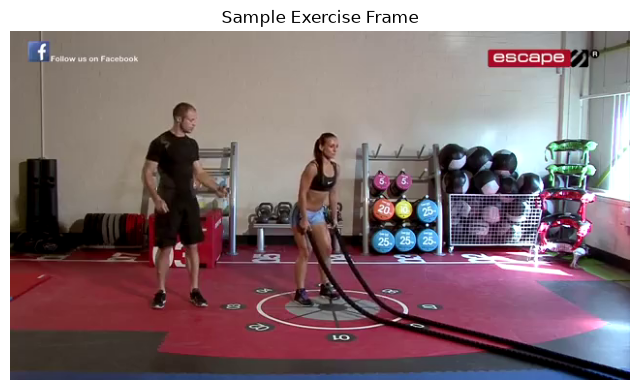

In [15]:
plt.figure(figsize=(8, 5))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Sample Exercise Frame")

plt.show()

### Observations

- The sample exercise video was loaded successfully.
- Video properties were extracted correctly.
- The first frame was read and displayed successfully.
- The exercise video is ready for pose detection.

## MediaPipe Pose

In [16]:
# Initialize Pose Estimator
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

In [17]:
# Detect Pose Landmarks
rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

results = pose.process(rgb_frame)

c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [18]:
# Draw Pose Landmarks
output_frame = frame.copy()

if results.pose_landmarks:
    mp_drawing.draw_landmarks(
        output_frame,
        results.pose_landmarks,
        mp_pose.POSE_CONNECTIONS,
    )

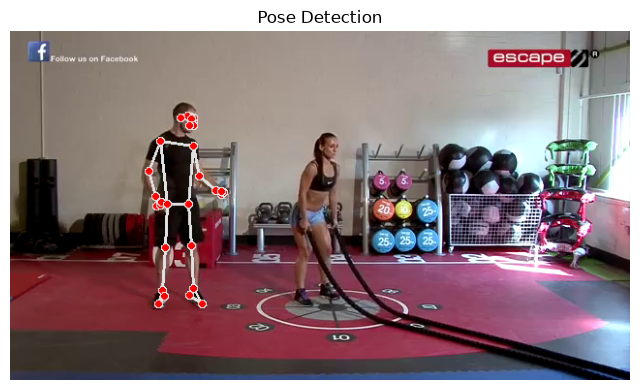

In [19]:
# Display Result
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB))
plt.title("Pose Detection")
plt.axis("off")
plt.show()

## Observations

- MediaPipe Pose was initialized successfully.
- Pose landmarks were detected on the sample frame.
- The detected skeleton was drawn correctly.
- The pipeline is ready for landmark extraction.

## Landmark Extraction

In [20]:
# Total Pose Landmarks

if results.pose_landmarks:

    total_landmarks = len(results.pose_landmarks.landmark)

    print(f"Total Pose Landmarks : {total_landmarks}")

else:

    print("No pose detected.")

Total Pose Landmarks : 33


### Observations

- Human pose was detected successfully.
- A total of **33 pose landmarks** were extracted.
- These landmarks will be used for feature engineering.

In [21]:
# Extract Pose Landmark Coordinates

landmarks = []

for landmark_id, landmark in enumerate(results.pose_landmarks.landmark):

    landmarks.append({
        "Landmark_ID": landmark_id,
        "X": landmark.x,
        "Y": landmark.y,
        "Z": landmark.z,
        "Visibility": landmark.visibility
    })

landmarks_df = pd.DataFrame(landmarks)

landmarks_df

,Landmark_ID,X,Y,Z,Visibility
0,0,0.295365,0.259771,-0.229916,0.999911
1,1,0.295193,0.247627,-0.215664,0.999675
2,2,0.295958,0.247849,-0.215684,0.999649
3,3,0.296754,0.248050,-0.215704,0.999625
4,4,0.291416,0.245962,-0.227418,0.999724
5,5,0.288945,0.245028,-0.227410,0.999689
6,6,0.286218,0.244230,-0.227393,0.999663
7,7,0.292637,0.251286,-0.122977,0.999111
8,8,0.276214,0.247955,-0.178578,0.999460
9,9,0.295435,0.272059,-0.193829,0.999694


### Observations

- All 33 pose landmarks were extracted successfully.
- Each landmark contains X, Y, Z coordinates and a visibility score.
- The extracted landmarks were converted into a structured DataFrame.
- The DataFrame is ready for feature engineering.

In [22]:
print(f"Landmark DataFrame Shape : {landmarks_df.shape}")

Landmark DataFrame Shape : (33, 5)


### Observations

- The DataFrame contains 33 body landmarks.
- Five attributes are available for every landmark.
- The extracted landmark data is ready for the next stage of the pipeline.

## Landmark Visualization

In [23]:
# Display Landmark DataFrame Statistics

landmarks_df.describe()

,Landmark_ID,X,Y,Z,Visibility
count,33.00000,33.000000,33.000000,33.000000,33.000000
mean,16.00000,0.282157,0.449568,-0.118504,0.976959
std,9.66954,0.033090,0.186454,0.115395,0.036236
min,0.00000,0.223815,0.244230,-0.258858,0.831648
25%,8.00000,0.248833,0.259771,-0.215704,0.964390
50%,16.00000,0.290119,0.460029,-0.162213,0.986940
75%,24.00000,0.295958,0.500044,-0.009917,0.999663
max,32.00000,0.344818,0.783197,0.093746,0.999911


### Observations

- Summary statistics were generated successfully for all 33 pose landmarks.
- The X, Y, and Z coordinates are normalized values produced by MediaPipe Pose.
- Visibility scores are consistently high, indicating reliable landmark detection.
- No abnormal variation or inconsistency is observed in the extracted landmark features.
- The landmark statistics confirm that the data is suitable for the feature engineering stage.|

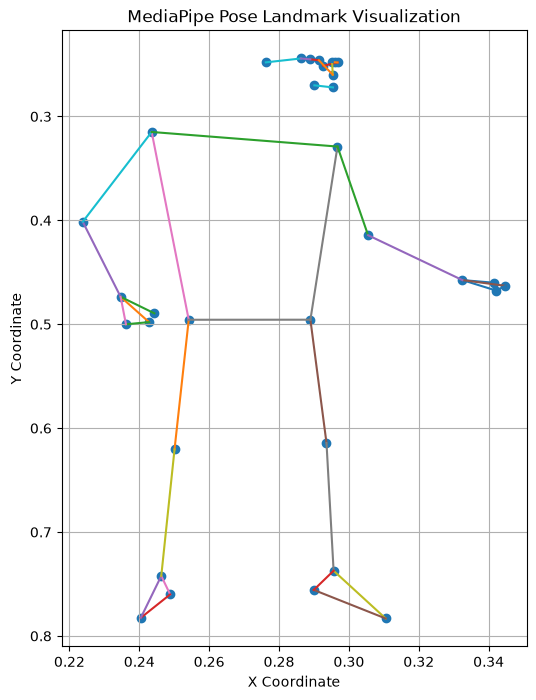

In [24]:
# Landmark Visualization (2D Plot)

import matplotlib.pyplot as plt

landmark_x = []
landmark_y = []

for landmark in results.pose_landmarks.landmark:
    landmark_x.append(landmark.x)
    landmark_y.append(landmark.y)


plt.figure(figsize=(6,8))

plt.scatter(landmark_x, landmark_y)

# Connect landmarks using MediaPipe pose connections
for connection in mp_pose.POSE_CONNECTIONS:
    start_idx, end_idx = connection
    
    plt.plot(
        [landmark_x[start_idx], landmark_x[end_idx]],
        [landmark_y[start_idx], landmark_y[end_idx]]
    )

plt.gca().invert_yaxis()
plt.title("MediaPipe Pose Landmark Visualization")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid()

plt.show()

## Observations

- MediaPipe Pose successfully detected the human body structure.
- A total of 33 body landmarks were extracted.
- The extracted landmarks were visualized using a 2D skeleton representation.
- The visualization confirmed the correct positioning and connectivity of body keypoints.
- These landmarks will be converted into numerical features for further model training.

# Label Extraction & Verification

In [25]:
# Load Exercise Annotation Dataset

import pandas as pd

# Display annotation dataframe
exercise_train_df.head()

,Unnamed: 0,type,name,count,L1,L2,L3,L4,L5,L6,...,L293,L294,L295,L296,L297,L298,L299,L300,L301,L302
0,0,frontraise,train951.mp4,4.0,6.0,72.0,72.0,132.0,132.0,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,frontraise,train952.mp4,10.0,13.0,62.0,62.0,103.0,103.0,126.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,pullups,test1463.mp4,7.0,21.0,60.0,60.0,98.0,98.0,132.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,squant,test2340.mp4,4.0,0.0,86.0,86.0,155.0,155.0,218.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,front_raise,stu5_11.mp4,6.0,104.0,179.0,179.0,255.0,255.0,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Check available columns

exercise_train_df.columns

Index(['Unnamed: 0', 'type', 'name', 'count', 'L1', 'L2', 'L3', 'L4', 'L5',
       'L6',
       ...
       'L293', 'L294', 'L295', 'L296', 'L297', 'L298', 'L299', 'L300', 'L301',
       'L302'],
      dtype='object', length=306)

In [27]:
# Dataset information

exercise_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Columns: 306 entries, Unnamed: 0 to L302
dtypes: float64(303), int64(1), object(2)
memory usage: 1.8+ MB


In [28]:
# Display sample annotation records

exercise_train_df.sample(5)

,Unnamed: 0,type,name,count,L1,L2,L3,L4,L5,L6,...,L293,L294,L295,L296,L297,L298,L299,L300,L301,L302
347,347,front_raise,stu8_21.mp4,3.0,45.0,146.0,146.0,239.0,239.0,327.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239,239,bench_pressing,stu4_7.mp4,12.0,31.0,88.0,88.0,150.0,150.0,216.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
401,401,benchpressing,test118.mp4,6.0,0.0,41.0,41.0,89.0,90.0,174.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
394,394,squant,val1258.mp4,3.0,5.0,90.0,90.0,204.0,204.0,299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200,200,pull_up,stu5_35.mp4,11.0,16.0,88.0,88.0,149.0,149.0,222.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Check available exercise classes

exercise_train_df["type"].unique()

array(['frontraise', 'pullups', 'squant', 'front_raise', 'bench_pressing',
       'jump_jack', 'situp', 'benchpressing', 'squat', 'pull_up',
       'push_up', 'jumpjacks', 'pushups', 'others', 'battle_rope',
       'pommelhorse'], dtype=object)

## Video Label Mapping

In [30]:
# Create Video Name to Label Mapping

video_label_mapping = dict(
    zip(
        exercise_train_df["name"],
        exercise_train_df["type"]
    )
)

# Display sample mappings

list(video_label_mapping.items())[:10]


[('train951.mp4', 'frontraise'),
 ('train952.mp4', 'frontraise'),
 ('test1463.mp4', 'pullups'),
 ('test2340.mp4', 'squant'),
 ('stu5_11.mp4', 'front_raise'),
 ('stu9_2.mp4', 'bench_pressing'),
 ('stu6_18.mp4', 'jump_jack'),
 ('stu4_14.mp4', 'front_raise'),
 ('stu8_3.mp4', 'bench_pressing'),
 ('stu4_54.mp4', 'situp')]

### Label Verification Function

In [31]:
def get_video_label(video_name, label_mapping):
    """
    Fetch exercise label using video name.
    """
    
    return label_mapping.get(video_name, None)

In [32]:
# Test label extraction on sample video

sample_video_name = sample_video_path.name

sample_label = get_video_label(
    sample_video_name,
    video_label_mapping
)

print("Video Name :", sample_video_name)
print("Label      :", sample_label)

Video Name : stu10_0.mp4
Label      : battle_rope


### Visual Label Verification

In [33]:
def verify_video_label(video_path, label_mapping):
    """
    Verify annotation label with actual video frame.
    """

    # Get video name
    video_name = video_path.name

    # Fetch label
    label = label_mapping.get(video_name, None)

    # Open video
    cap = cv2.VideoCapture(str(video_path))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Read middle frame
    middle_frame = total_frames // 2

    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)

    ret, frame = cap.read()

    cap.release()

    if not ret:
        print("Frame extraction failed")
        return


    # Convert BGR to RGB
    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )


    # Display information
    print("Video Name :", video_name)
    print("Assigned Label :", label)


    # Display frame
    plt.figure(figsize=(8,5))
    plt.imshow(frame_rgb)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

Video Name : stu10_0.mp4
Assigned Label : battle_rope


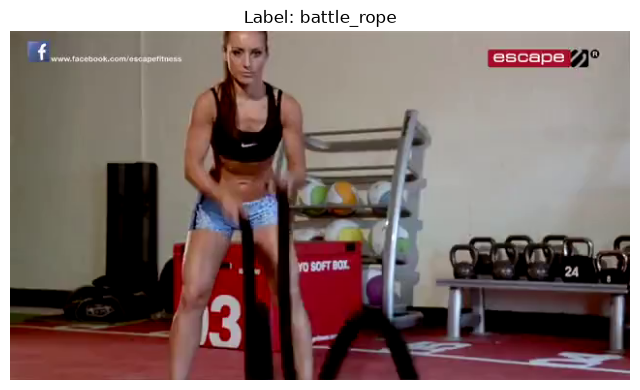

In [34]:
# Verify sample video

verify_video_label(
    sample_video_path,
    video_label_mapping
)

## Observations

- Video names were successfully mapped with corresponding exercise labels from annotation data.
- A sample video was extracted and compared with its assigned annotation label.
- The visual verification confirmed that the annotation label matches the actual exercise performed in the video.
- The label mapping pipeline is ready for automated feature extraction.

# Exercise Feature Extraction Pipeline

## Pose Feature Extraction Function

In [35]:
def extract_pose_features(frame, pose_model):
    """
    Extract 132 pose features from a single frame.

    MediaPipe Pose:
    33 landmarks × 4 values
    (x, y, z, visibility)

    Returns:
        list of 132 features
    """

    # Convert BGR image to RGB
    rgb_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Detect pose landmarks
    results = pose_model.process(rgb_frame)

    # If no pose detected
    if not results.pose_landmarks:
        return None

    features = []

    # Extract landmark values
    for landmark in results.pose_landmarks.landmark:

        features.extend([
            landmark.x,
            landmark.y,
            landmark.z,
            landmark.visibility
        ])

    return features

In [36]:
# Extract features from sample frame

pose_features = extract_pose_features(
    frame,
    pose
)


if pose_features is not None:
    print("Feature Extraction Successful")
    print("Feature Length :", len(pose_features))

else:
    print("No Pose Detected")

Feature Extraction Successful
Feature Length : 132


c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


## Observations

- A reusable pose feature extraction function was successfully implemented.
- MediaPipe Pose landmarks were converted into numerical feature vectors.
- Each detected pose generated 132 features consisting of 33 landmarks with X, Y, Z coordinates and visibility values.
- The feature extraction pipeline is ready to be integrated with video-level processing.

## Process Exercise Video Function

In [37]:
from tqdm import tqdm


def process_exercise_video(
    video_path,
    label_mapping,
    pose_model,
    frame_skip=5
):
    """
    Process a single exercise video.

    Steps:
    Video
        ↓
    Extract Label
        ↓
    Read Frames
        ↓
    Frame Sampling
        ↓
    Pose Feature Extraction
        ↓
    Store Features + Metadata

    Returns:
        List of dictionaries
    """


    # Extract video name
    video_name = video_path.name


    # Get exercise label
    label = label_mapping.get(video_name)


    if label is None:
        print(f"Label not found: {video_name}")
        return []


    # Open video
    cap = cv2.VideoCapture(
        str(video_path)
    )


    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )


    records = []

    frame_number = 0


    # Progress bar for frames
    with tqdm(
        total=total_frames,
        desc=f"Processing {video_name}"
    ) as progress:


        while True:

            ret, frame = cap.read()


            if not ret:
                break


            # Process every nth frame
            if frame_number % frame_skip == 0:


                features = extract_pose_features(
                    frame,
                    pose_model
                )


                if features is not None:

                    record = {

                        "Video_Name": video_name,

                        "Label": label,

                        "Frame_Number": frame_number

                    }


                    # Add 132 pose features
                    for idx, value in enumerate(features):

                        record[
                            f"Feature_{idx+1}"
                        ] = value


                    records.append(record)


            frame_number += 1

            progress.update(1)


    cap.release()


    return records

## Single Video Feature Extraction Test

In [38]:
# Select sample exercise video

sample_video_path = exercise_train_videos[0]


# Process single video

sample_records = process_exercise_video(
    video_path=sample_video_path,
    label_mapping=video_label_mapping,
    pose_model=pose,
    frame_skip=5
)


# Convert output to dataframe

sample_features_df = pd.DataFrame(sample_records)


# Display shape

print("Dataset Shape:", sample_features_df.shape)


# Display sample data

sample_features_df.head()

Processing stu10_0.mp4: 100%|██████████| 250/250 [00:01<00:00, 187.79it/s]

Dataset Shape: (49, 135)


,Video_Name,Label,Frame_Number,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,...,Feature_123,Feature_124,Feature_125,Feature_126,Feature_127,Feature_128,Feature_129,Feature_130,Feature_131,Feature_132
0,stu10_0.mp4,battle_rope,0,0.295261,0.260853,-0.194339,0.999925,0.295173,0.249371,-0.180631,...,0.061533,0.845161,0.309918,0.781030,-0.097487,0.978785,0.240292,0.783211,-0.031687,0.975583
1,stu10_0.mp4,battle_rope,5,0.293879,0.262280,-0.221568,0.999931,0.292959,0.250900,-0.212147,...,0.063800,0.850622,0.309862,0.781039,-0.035511,0.979764,0.240289,0.784339,-0.018291,0.976831
2,stu10_0.mp4,battle_rope,10,0.293043,0.258955,-0.244647,0.999926,0.291506,0.247631,-0.233226,...,0.135441,0.856715,0.309439,0.780918,0.006263,0.981092,0.240321,0.784249,0.041807,0.978211
3,stu10_0.mp4,battle_rope,15,0.291607,0.259972,-0.248792,0.999931,0.290734,0.248302,-0.237267,...,0.064333,0.859582,0.310229,0.780330,0.006929,0.980733,0.240365,0.784862,-0.030836,0.978429
4,stu10_0.mp4,battle_rope,20,0.290705,0.259251,-0.215238,0.999933,0.290334,0.247801,-0.201663,...,0.068993,0.861005,0.310207,0.765371,-0.003637,0.980444,0.239454,0.784648,-0.017364,0.978424


## Observations

- A complete single exercise video processing pipeline was successfully implemented.
- The video was processed frame-by-frame using OpenCV with frame sampling.
- MediaPipe Pose successfully extracted body landmarks from selected frames.
- Each detected pose was converted into a 132-dimensional feature vector.
- Exercise labels were automatically integrated using annotation-based video mapping.
- The generated feature dataset contains pose features along with video name, label, and frame information.
- The pipeline is ready for large-scale processing of the complete exercise video dataset.

## Full Exercise Dataset Feature Extraction

from tqdm import tqdm


exercise_records = []


for video_path in tqdm(
    exercise_train_videos,
    desc="Processing Exercise Videos"
):

    video_records = process_exercise_video(
        video_path=video_path,
        label_mapping=video_label_mapping,
        pose_model=pose,
        frame_skip=5
    )

    exercise_records.extend(video_records)


print("Total Extracted Records:", len(exercise_records))

## Exercise Pose Feature Extraction Completed

- Total videos processed: 758
- Pose landmarks extracted using MediaPipe
- Frame-level features generated successfully
- Feature dataset saved for further analysis and model training

The extracted dataset will be loaded directly in future runs to avoid repeating the expensive video processing step.

## Exercise Feature Dataset Creation


### Exercise Feature Dataset Creation (Completed)

The extracted pose records were converted into a structured DataFrame and saved as a processed feature dataset.

Future runs should directly load the saved CSV file.


##Convert Extracted Records into DataFrame

exercise_features_df = pd.DataFrame(
    exercise_records
)


##Display Dataset Shape

print(
    "Dataset Shape:",
    exercise_features_df.shape
)


##Display First Few Records

exercise_features_df.head()

In [39]:
# Load Previously Extracted Exercise Feature Dataset

FEATURE_PATH = "processed_data/exercise_pose_features.csv"


exercise_features_df = pd.read_csv(
    FEATURE_PATH
)


print("Feature Dataset Loaded Successfully")


print(
    "Dataset Shape:",
    exercise_features_df.shape
)


exercise_features_df.head()

Feature Dataset Loaded Successfully
Dataset Shape: (119111, 135)


,Video_Name,Label,Frame_Number,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,...,Feature_123,Feature_124,Feature_125,Feature_126,Feature_127,Feature_128,Feature_129,Feature_130,Feature_131,Feature_132
0,stu10_0.mp4,battle_rope,0,0.293090,0.259786,-0.287153,0.996254,0.294207,0.247883,-0.269210,...,0.098174,0.665810,0.314813,0.786834,-0.038357,0.795259,0.245318,0.788941,-0.007398,0.795422
1,stu10_0.mp4,battle_rope,5,0.290041,0.263404,-0.300472,0.996604,0.289302,0.250148,-0.288008,...,0.126523,0.684686,0.308184,0.781395,0.027400,0.812832,0.242571,0.784060,0.026298,0.813073
2,stu10_0.mp4,battle_rope,10,0.289640,0.258916,-0.249147,0.996919,0.289413,0.246393,-0.236047,...,0.161843,0.700924,0.306367,0.780828,0.064976,0.829895,0.242559,0.785089,0.063555,0.829658
3,stu10_0.mp4,battle_rope,15,0.289758,0.261827,-0.281750,0.997220,0.289673,0.250113,-0.269019,...,0.113706,0.718042,0.309000,0.776225,0.011207,0.844202,0.242385,0.786984,-0.024372,0.844508
4,stu10_0.mp4,battle_rope,20,0.289781,0.259118,-0.194682,0.997484,0.289732,0.247599,-0.180877,...,0.085388,0.732602,0.313394,0.763798,-0.037751,0.856398,0.239968,0.781185,-0.004940,0.856392


## Save Processed Exercise Feature Dataset

In [40]:
# Save Processed Exercise Feature Dataset

import os

# Create processed data directory
os.makedirs(
    "processed_data",
    exist_ok=True
)


# Save Feature Dataset
FEATURE_PATH = "processed_data/exercise_pose_features.csv"


exercise_features_df.to_csv(
    FEATURE_PATH,
    index=False
)


print("Exercise Feature Dataset Saved Successfully")

Exercise Feature Dataset Saved Successfully


In [41]:
# Check Saved Feature Dataset

os.path.exists(
    FEATURE_PATH
)

True

## Exercise Feature Dataset Analysis

In [42]:
# Check Dataset Columns

print("Total Columns:", len(exercise_features_df.columns))

print("\nDataset Columns:")

print(exercise_features_df.columns.tolist())

Total Columns: 135

Dataset Columns:
['Video_Name', 'Label', 'Frame_Number', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20', 'Feature_21', 'Feature_22', 'Feature_23', 'Feature_24', 'Feature_25', 'Feature_26', 'Feature_27', 'Feature_28', 'Feature_29', 'Feature_30', 'Feature_31', 'Feature_32', 'Feature_33', 'Feature_34', 'Feature_35', 'Feature_36', 'Feature_37', 'Feature_38', 'Feature_39', 'Feature_40', 'Feature_41', 'Feature_42', 'Feature_43', 'Feature_44', 'Feature_45', 'Feature_46', 'Feature_47', 'Feature_48', 'Feature_49', 'Feature_50', 'Feature_51', 'Feature_52', 'Feature_53', 'Feature_54', 'Feature_55', 'Feature_56', 'Feature_57', 'Feature_58', 'Feature_59', 'Feature_60', 'Feature_61', 'Feature_62', 'Feature_63', 'Feature_64', 'Feature_65', 'Feature_66', 'Feature

In [43]:
# Dataset Information

exercise_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119111 entries, 0 to 119110
Columns: 135 entries, Video_Name to Feature_132
dtypes: float64(132), int64(1), object(2)
memory usage: 122.7+ MB


In [44]:
# Check Missing Values

total_missing = exercise_features_df.isnull().sum().sum()

print(
    "Total Missing Values:",
    total_missing
)

Total Missing Values: 0


## Observations

- The final exercise feature dataset contains 119,111 frame-level samples.
- A total of 135 columns were generated, including:
    - 3 metadata columns (Video_Name, Label, Frame_Number)
    - 132 MediaPipe pose landmark features.
- All extracted pose features are numeric and ready for machine learning.
- No missing values were detected in the dataset.
- The dataset is clean and ready for the preprocessing stage.

In [45]:
# Check Total Exercise Classes

total_classes = exercise_features_df["Label"].nunique()

print(
    "Total Exercise Classes:",
    total_classes
)

Total Exercise Classes: 16


In [46]:
# Count Samples per Exercise Class

class_distribution = (
    exercise_features_df["Label"]
    .value_counts()
)


class_distribution

Label
push_up           17228
squat             16356
situp             16158
pull_up           15604
bench_pressing    14950
jump_jack         10296
front_raise        9334
pommelhorse        7606
others             4571
frontraise         1398
battle_rope        1134
squant             1102
pullups             942
pushups             876
jumpjacks           779
benchpressing       777
Name: count, dtype: int64

In [47]:
# Create Class Distribution DataFrame

class_distribution_df = (
    class_distribution
    .reset_index()
)


class_distribution_df.columns = [
    "Exercise_Class",
    "Sample_Count"
]


class_distribution_df.head()

,Exercise_Class,Sample_Count
0,push_up,17228
1,squat,16356
2,situp,16158
3,pull_up,15604
4,bench_pressing,14950


C:\Users\panig\AppData\Local\Temp\ipykernel_20716\2783410831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


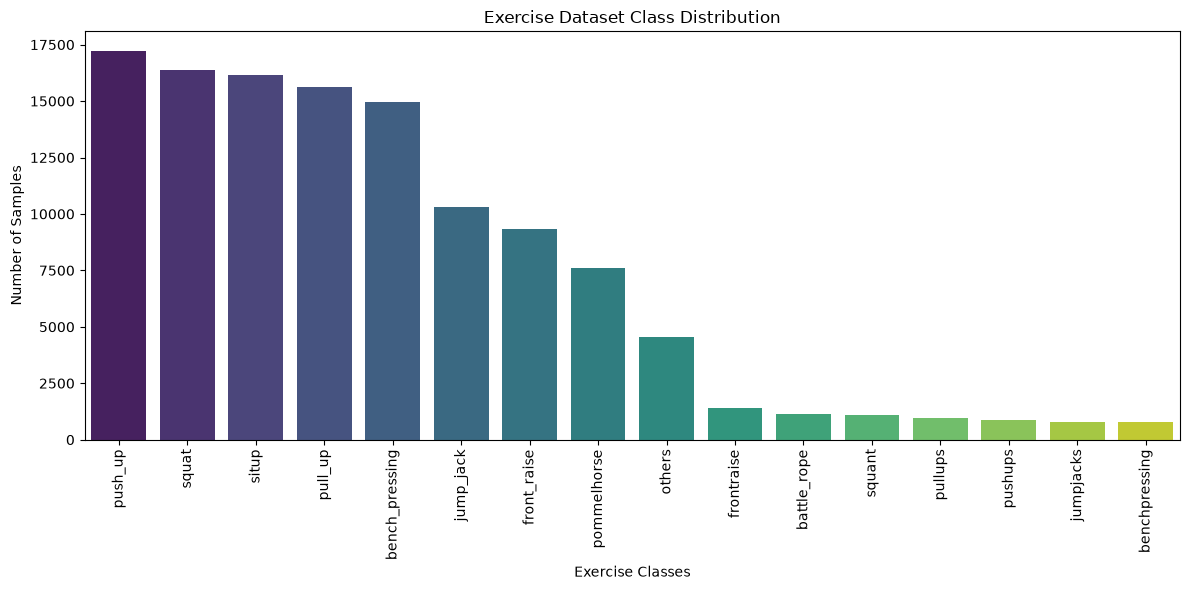

In [48]:
plt.figure(figsize=(12,6))


sns.barplot(
    data=class_distribution_df,
    x="Exercise_Class",
    y="Sample_Count",
    palette="viridis"
)


plt.xticks(
    rotation=90
)


plt.xlabel("Exercise Classes")

plt.ylabel("Number of Samples")


plt.title(
    "Exercise Dataset Class Distribution"
)


plt.tight_layout()

plt.show()

## Observations

- The exercise dataset contains 16 unique classes with 119,111 frame-level samples.
- Class distribution analysis shows variations in sample availability among different exercises.
- Major classes such as push_up, squat, situp, and pull_up contain the highest number of samples.
- Some classes have lower representation due to duplicate naming conventions for similar exercises.
- Label normalization is required to merge semantically identical exercise categories before model training.

In [49]:
print(
    "Maximum Samples:",
    class_distribution_df["Sample_Count"].max()
)


print(
    "Minimum Samples:",
    class_distribution_df["Sample_Count"].min()
)


print(
    "Average Samples:",
    class_distribution_df["Sample_Count"].mean()
)

Maximum Samples: 17228
Minimum Samples: 777
Average Samples: 7444.4375


## Observations

- The exercise dataset contains 16 unique exercise classes with 119,111 frame-level samples.
- Class distribution analysis shows variations in sample availability across different exercises.
- Major classes such as push_up, squat, situp, and pull_up contain the highest number of samples.
- Some classes have lower representation due to inconsistent naming conventions for similar exercises.
- Duplicate class labels were identified and require normalization before model training.

## Label Normalization

In [50]:
# Normalize Duplicate Exercise Labels

label_mapping = {

    "pushups": "push_up",
    "pullups": "pull_up",
    "jumpjacks": "jump_jack",
    "benchpressing": "bench_pressing",
    "frontraise": "front_raise",
    "squant": "squat"

}


# Apply Label Mapping

exercise_features_df["Label"] = (
    exercise_features_df["Label"]
    .replace(label_mapping)
)


print("Label Normalization Completed")

Label Normalization Completed


In [51]:
# Check Updated Exercise Classes

print(
    "Total Classes After Normalization:",
    exercise_features_df["Label"].nunique()
)


print("\nUpdated Classes:")

print(
    exercise_features_df["Label"].unique()
)

Total Classes After Normalization: 10

Updated Classes:
['battle_rope' 'bench_pressing' 'front_raise' 'jump_jack' 'others'
 'pull_up' 'push_up' 'situp' 'squat' 'pommelhorse']


In [52]:
# Updated Class Distribution

exercise_features_df["Label"].value_counts()

Label
push_up           18104
squat             17458
pull_up           16546
situp             16158
bench_pressing    15727
jump_jack         11075
front_raise       10732
pommelhorse        7606
others             4571
battle_rope        1134
Name: count, dtype: int64

## Observations

- Duplicate exercise labels were successfully normalized.
- The number of exercise classes reduced from 16 to 10 after merging semantically identical categories.
- Label consistency was improved by combining multiple names representing the same exercise.
- The cleaned labels will help the machine learning model learn distinct exercise patterns more effectively.
- The final dataset is ready for feature-target separation and model training.

## Others Class Analysis

In [53]:
# Check Videos Belonging to Others Class

others_videos = (
    exercise_features_df[
        exercise_features_df["Label"] == "others"
    ]["Video_Name"]
    .unique()
)


print(
    "Total Others Videos:",
    len(others_videos)
)


print("\nOthers Class Videos:")

for video in others_videos:
    print(video)

Total Others Videos: 37

Others Class Videos:
stu10_32.mp4
stu10_33.mp4
stu11_0.mp4
stu11_1.mp4
stu11_10.mp4
stu11_11.mp4
stu11_12.mp4
stu11_13.mp4
stu11_2.mp4
stu11_3.mp4
stu11_4.mp4
stu11_5.mp4
stu11_6.mp4
stu11_7.mp4
stu11_8.mp4
stu11_9.mp4
stu12_0.mp4
stu12_1.mp4
stu12_10.mp4
stu12_2.mp4
stu12_3.mp4
stu12_4.mp4
stu12_5.mp4
stu12_6.mp4
stu12_7.mp4
stu12_8.mp4
stu12_9.mp4
stu13_0.mp4
stu13_1.mp4
stu13_2.mp4
stu13_3.mp4
stu13_4.mp4
stu13_5.mp4
stu13_6.mp4
stu1_28.mp4
stu1_29.mp4
stu5_28.mp4


In [54]:
# Analyze original exercises inside "others"

others_video_names = (
    exercise_features_df[
        exercise_features_df["Label"] == "others"
    ]["Video_Name"]
    .unique()
)


others_analysis = exercise_train_df[
    exercise_train_df["name"].isin(others_video_names)
]


others_analysis["type"].value_counts()

type
others    37
Name: count, dtype: int64

## Others Class Image Visualization

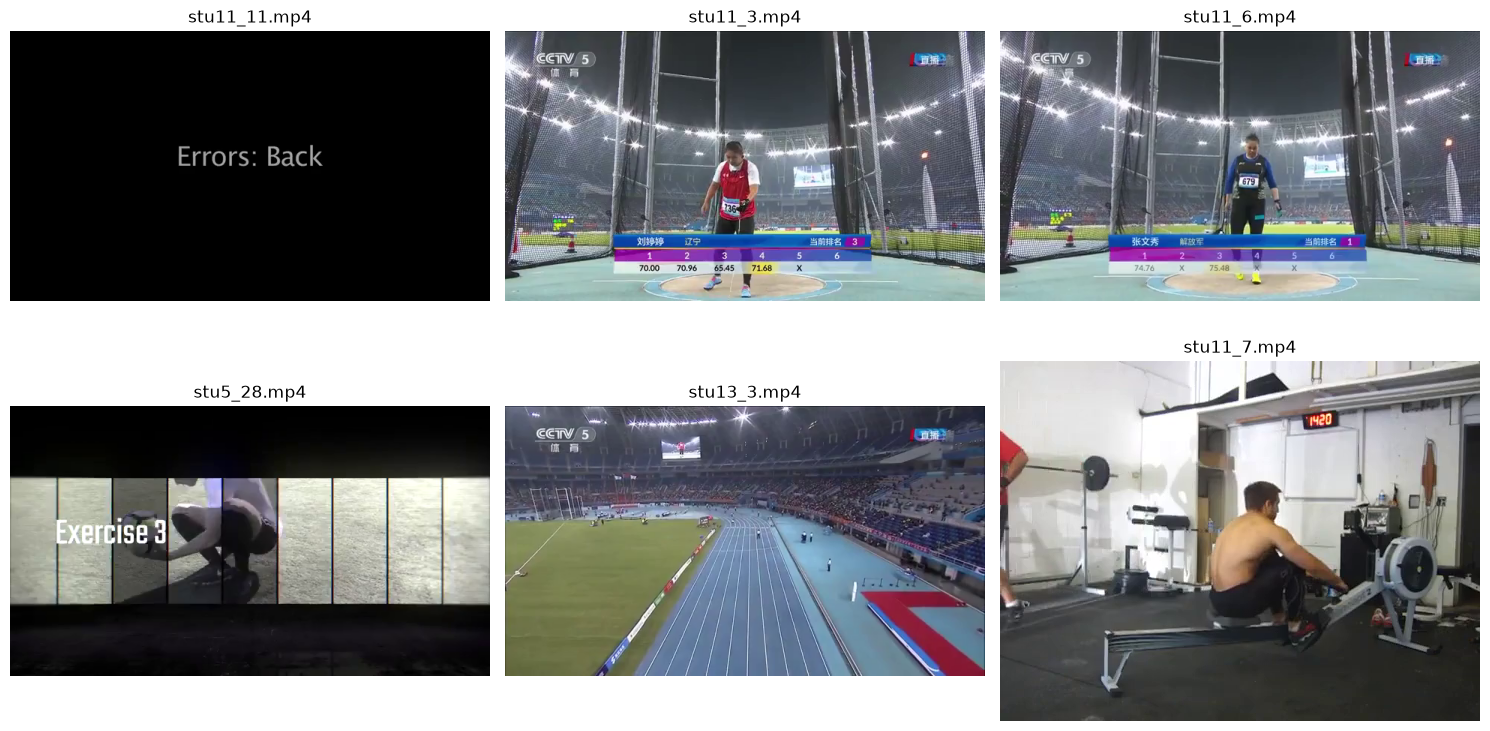

In [55]:
# Visualize random samples from "others" class for manual inspection

# Select random others class videos

others_videos = (
    exercise_features_df[
        exercise_features_df["Label"] == "others"
    ]["Video_Name"]
    .unique()
)


sample_videos = random.sample(
    list(others_videos),
    6
)


# Search and display video frames

video_folders = [
    EXERCISE_VIDEO_DIR / "train",
    EXERCISE_VIDEO_DIR / "test",
    EXERCISE_VIDEO_DIR / "valid"
]


plt.figure(figsize=(15,8))


for index, video_name in enumerate(sample_videos):

    video_path = None

    for folder in video_folders:

        temp_path = folder / video_name

        if temp_path.exists():
            video_path = temp_path
            break


    if video_path:

        cap = cv2.VideoCapture(str(video_path))

        ret, frame = cap.read()

        cap.release()


        if ret:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            plt.subplot(2,3,index+1)

            plt.imshow(frame)

            plt.title(video_name)

            plt.axis("off")


plt.tight_layout()

plt.show()

## Observations

- Random samples from the "others" class were visually inspected.
- The class contains highly diverse activities, including rowing, football-related movements, athletics, and non-exercise frames.
- These samples do not represent a specific exercise movement pattern.
- Keeping this class may increase model confusion during classification.
- Therefore, the "others" class is removed to maintain consistent exercise categories and improve model performance.

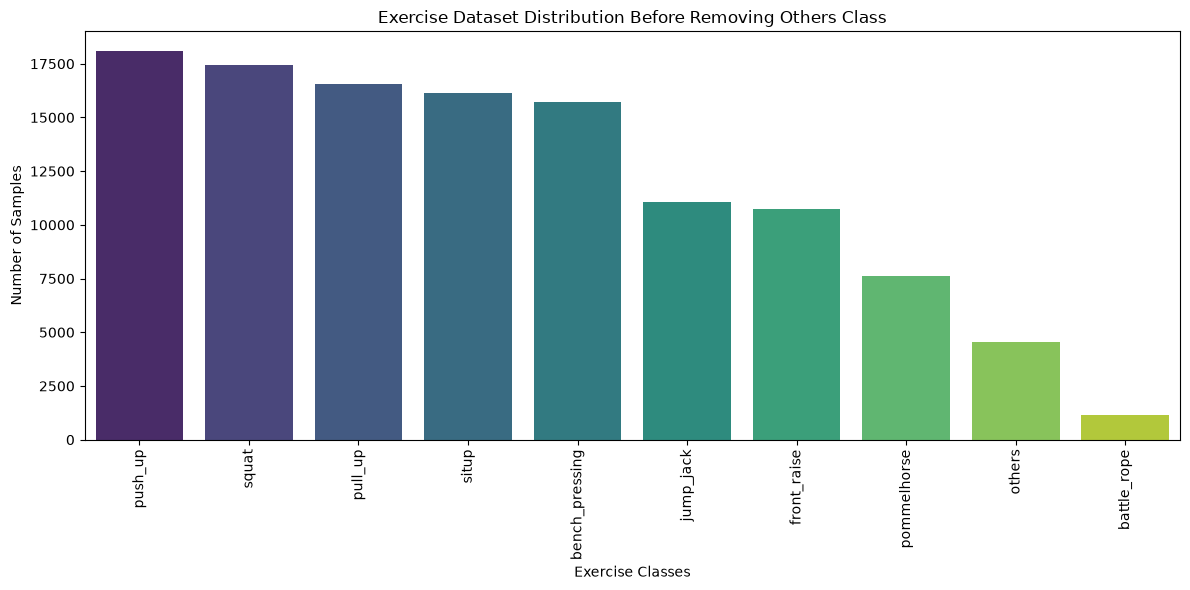

In [56]:

# Class distribution before removing others

others_distribution = (
    exercise_features_df["Label"]
    .value_counts()
    .reset_index()
)


others_distribution.columns = [
    "Exercise_Class",
    "Sample_Count"
]


plt.figure(figsize=(12,6))


sns.barplot(
    data=others_distribution,
    x="Exercise_Class",
    y="Sample_Count",
    hue="Exercise_Class",
    palette="viridis",
    legend=False
)


plt.xticks(
    rotation=90
)


plt.xlabel("Exercise Classes")

plt.ylabel("Number of Samples")


plt.title(
    "Exercise Dataset Distribution Before Removing Others Class"
)


plt.tight_layout()

plt.show()

## Observations

- The class distribution was analyzed before removing the "others" category.
- The "others" class contains 4,571 samples, but these samples do not represent a consistent exercise movement.
- Compared with other exercise classes, the "others" category may introduce noise during model training.
- The class will be removed to maintain well-defined exercise categories.

## Remove Others Class

In [57]:
# Remove inconsistent "others" class from dataset

exercise_features_df = (
    exercise_features_df[
        exercise_features_df["Label"] != "others"
    ]
    .reset_index(drop=True)
)


print("Others Class Removed Successfully")

print(
    "Remaining Classes:",
    exercise_features_df["Label"].nunique()
)

Others Class Removed Successfully
Remaining Classes: 9


In [58]:
# Verify Remaining Exercise Classes

exercise_features_df["Label"].value_counts()

Label
push_up           18104
squat             17458
pull_up           16546
situp             16158
bench_pressing    15727
jump_jack         11075
front_raise       10732
pommelhorse        7606
battle_rope        1134
Name: count, dtype: int64

## Observations

- The "others" class was removed after visual inspection due to inconsistent activity patterns.
- The dataset now contains only well-defined exercise categories.
- The final exercise classes represent more consistent movement patterns for model training.
- Removing ambiguous samples helps reduce model confusion and improves classification performance.

## Final Exercise Dataset Summary

In [59]:
# Generate final dataset summary after cleaning

print("Final Dataset Shape:")
print(exercise_features_df.shape)


print("\nFinal Classes:")
print(
    exercise_features_df["Label"].unique()
)


print("\nMissing Values:")
print(
    exercise_features_df.isnull().sum().sum()
)

Final Dataset Shape:
(114540, 135)

Final Classes:
['battle_rope' 'bench_pressing' 'front_raise' 'jump_jack' 'pull_up'
 'push_up' 'situp' 'squat' 'pommelhorse']

Missing Values:
0


## Observations

- The final dataset contains 114,540 frame-level samples with 135 total features.
- The dataset consists of 9 exercise classes after cleaning.
- No missing values were found in the final dataset.
- The cleaned dataset is ready for feature-target separation and model development.

## Feature and Target Separation

In [60]:
# Separate Input Features and Target Label

# Remove non-feature columns
X = exercise_features_df.drop(
    columns=[
        "Video_Name",
        "Label",
        "Frame_Number"
    ]
)


# Target variable
y = exercise_features_df["Label"]


print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (114540, 132)
Target Shape: (114540,)


### Observation

- Non-feature columns such as Video_Name and Frame_Number were removed as they do not contribute to model learning.
- The final input dataset contains 132 pose-based numerical features extracted from MediaPipe landmarks.
- The Label column was separated as the target variable for multi-class exercise classification.
- The prepared dataset contains 114,540 samples ready for model training.

## Label Encoding

In [62]:
# Encode Exercise Labels into Numerical Classes

from sklearn.preprocessing import LabelEncoder


# Initialize Label Encoder
label_encoder = LabelEncoder()


# Transform labels
y_encoded = label_encoder.fit_transform(y)


# Display class mapping

class_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)


print("Class Mapping:")
print(class_mapping)


print("\nEncoded Target Sample:")
print(y_encoded[:10])

Class Mapping:
{'battle_rope': 0, 'bench_pressing': 1, 'front_raise': 2, 'jump_jack': 3, 'pommelhorse': 4, 'pull_up': 5, 'push_up': 6, 'situp': 7, 'squat': 8}

Encoded Target Sample:
[0 0 0 0 0 0 0 0 0 0]


In [63]:
# Check Encoded Class Distribution

encoded_distribution = pd.Series(y_encoded).value_counts().sort_index()

encoded_distribution

0     1134
1    15727
2    10732
3    11075
4     7606
5    16546
6    18104
7    16158
8    17458
Name: count, dtype: int64

In [64]:
# Check Current Variables

print("Feature Variable (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

print("\nEncoded Target Variable (y_encoded):")
print(y_encoded[:10])

Feature Variable (X):
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0   0.293090   0.259786  -0.287153   0.996254   0.294207   0.247883   
1   0.290041   0.263404  -0.300472   0.996604   0.289302   0.250148   
2   0.289640   0.258916  -0.249147   0.996919   0.289413   0.246393   
3   0.289758   0.261827  -0.281750   0.997220   0.289673   0.250113   
4   0.289781   0.259118  -0.194682   0.997484   0.289732   0.247599   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_123  Feature_124  \
0  -0.269210   0.993722   0.295534    0.248208  ...     0.098174     0.665810   
1  -0.288008   0.994250   0.290135    0.250294  ...     0.126523     0.684686   
2  -0.236047   0.994744   0.290204    0.246686  ...     0.161843     0.700924   
3  -0.269019   0.995241   0.290460    0.250237  ...     0.113706     0.718042   
4  -0.180877   0.995670   0.290556    0.247810  ...     0.085388     0.732602   

   Feature_125  Feature_126  Feature_127  Feature_128  Feature_1

## Train-Test Split

In [66]:
# Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (91632, 132)
Testing Feature Shape: (22908, 132)

Training Target Shape: (91632,)
Testing Target Shape: (22908,)


### Observation

- The dataset was successfully divided into training and testing subsets using an 80:20 split ratio.
- Stratified splitting was applied to preserve the original distribution of exercise classes in both datasets.
- The training dataset contains 91,632 samples with 132 pose-based features.
- The testing dataset contains 22,908 samples with 132 pose-based features for model evaluation.

## Feature Scaling

In [69]:
# Scale Numerical Features using StandardScaler

from sklearn.preprocessing import StandardScaler


# Initialize scaler
scaler = StandardScaler()


# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)


# Transform testing data using same scaler
X_test_scaled = scaler.transform(X_test)


print("Scaled Training Feature Shape:", X_train_scaled.shape)
print("Scaled Testing Feature Shape:", X_test_scaled.shape)

Scaled Training Feature Shape: (91632, 132)
Scaled Testing Feature Shape: (22908, 132)


In [70]:
# Check Feature Distribution After Scaling

print("Mean of first feature:", X_train_scaled[:,0].mean())
print("Standard Deviation of first feature:", X_train_scaled[:,0].std())

Mean of first feature: 4.606058855438051e-17
Standard Deviation of first feature: 0.9999999999999999


### Observation

- Numerical pose features were standardized using StandardScaler.
- The scaler was fitted only on the training data and applied to both training and testing datasets.
- After scaling, features have approximately zero mean and unit variance.
- The scaled datasets maintain the original feature dimensions of 132 pose features.

# Baseline Models Building

## Logistic Regression

Logistic Regression is selected as the baseline model because it provides a simple and fast approach for multi-class classification.
It helps establish initial performance and understand the relationship between extracted pose features and exercise classes.

In [71]:
# Train Logistic Regression Baseline Model

from sklearn.linear_model import LogisticRegression


# Initialize model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Train model
logistic_model.fit(
    X_train_scaled,
    y_train
)


# Generate predictions
y_pred_lr = logistic_model.predict(
    X_test_scaled
)


print("Logistic Regression Training Completed")

Logistic Regression Training Completed


## K-Nearest Neighbors (KNN)

KNN is selected because exercise pose features with similar body positions are expected to have similar feature patterns.
It provides a similarity-based approach to compare performance with the baseline linear model.

In [73]:
# Train K-Nearest Neighbors Classification Model

from sklearn.neighbors import KNeighborsClassifier


# Initialize KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)


# Train model
knn_model.fit(
    X_train_scaled,
    y_train
)


# Generate predictions
y_pred_knn = knn_model.predict(
    X_test_scaled
)


print("KNN Training Completed")

c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_inf

KNN Training Completed


## Decision Tree

Decision Tree is selected because it can learn non-linear relationships between pose features and exercise classes.
It provides interpretable decision rules and helps compare tree-based learning performance with linear and distance-based models.

In [74]:
# Train Decision Tree Classification Model

from sklearn.tree import DecisionTreeClassifier


# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)


# Train model
dt_model.fit(
    X_train_scaled,
    y_train
)


# Generate predictions
y_pred_dt = dt_model.predict(
    X_test_scaled
)


print("Decision Tree Training Completed")

Decision Tree Training Completed


## Random Forest

Random Forest is selected because it is an ensemble learning algorithm that can capture complex non-linear relationships in pose-based features.``
It combines multiple decision trees to improve generalization and reduce overfitting compared to a single decision tree.

In [76]:
# Train Random Forest Classification Model

from sklearn.ensemble import RandomForestClassifier


# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# Train model
rf_model.fit(
    X_train_scaled,
    y_train
)


# Generate predictions
y_pred_rf = rf_model.predict(
    X_test_scaled
)


print("Random Forest Training Completed")

Random Forest Training Completed


## XGBoost

XGBoost is selected because it is a powerful boosting algorithm that improves prediction performance by learning from previous model errors.
It is effective for structured numerical datasets and can capture complex patterns in exercise pose features.

In [78]:
# Train XGBoost Classification Model

from xgboost import XGBClassifier


# Initialize XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)


# Train model
xgb_model.fit(
    X_train_scaled,
    y_train
)


# Generate predictions
y_pred_xgb = xgb_model.predict(
    X_test_scaled
)


print("XGBoost Training Completed")

XGBoost Training Completed


### Observation

- Multiple machine learning classification models were successfully trained using the scaled pose feature dataset.
- Different learning approaches including linear, distance-based, tree-based, and ensemble algorithms were implemented for comparison.
- Predictions from each model were generated and stored for further evaluation.
- The performance of all trained models will be compared using evaluation metrics to select the best-performing classifier.

# Model Evaluation and Comparison

This section evaluates all trained classification models using accuracy, precision, recall, and F1-score to identify the best-performing model for exercise classification.

In [79]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [80]:
# Function to evaluate model performance

def evaluate_model(model_name, y_test, y_pred):
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    }

In [81]:
# Evaluate all trained models

model_results = []


model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)


model_results.append(
    evaluate_model(
        "KNN",
        y_test,
        y_pred_knn
    )
)


model_results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt
    )
)


model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)


model_results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb
    )
)


model_comparison_df = pd.DataFrame(model_results)


model_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.757596,0.753060,0.757596,0.752903
1,KNN,0.974419,0.974669,0.974419,0.974476
2,Decision Tree,0.912127,0.912254,0.912127,0.912155
3,Random Forest,0.981055,0.981156,0.981055,0.981076
4,XGBoost,0.959054,0.959129,0.959054,0.959053


### Observation

- All trained models were evaluated using Accuracy, Precision, Recall, and F1-score metrics.
- Logistic Regression achieved the lowest performance, indicating that exercise classification involves complex non-linear patterns.
- KNN performed significantly better due to similarity-based learning on pose feature patterns.
- Tree-based models achieved strong performance by capturing non-linear relationships between pose features and exercise classes.
- Random Forest achieved the highest performance among classical ML models with approximately 98.10% accuracy.
- Random Forest was selected as the best-performing classical machine learning model for further analysis.

## Model Performance Visualization

This visualization compares the performance of all trained machine learning models based on accuracy scores.

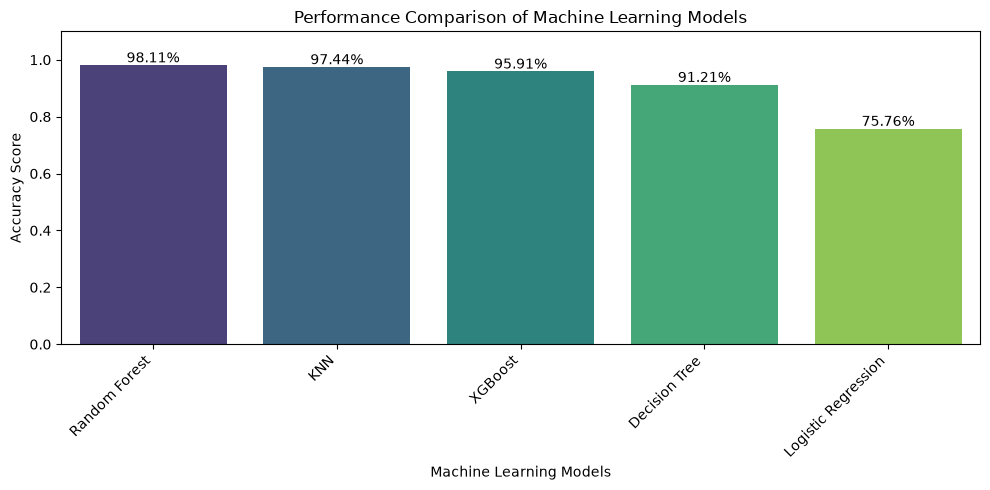

In [86]:
# Visualize Model Accuracy Comparison

# Improved Model Accuracy Comparison Visualization
model_accuracy_df = model_comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)


plt.figure(figsize=(10,5))


sns.barplot(
    data=model_accuracy_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)


# Add accuracy percentage labels manually
for i, value in enumerate(model_accuracy_df["Accuracy"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.2%}",
        ha="center",
        fontsize=10
    )


plt.ylim(0,1.1)

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy Score")

plt.title(
    "Performance Comparison of Machine Learning Models"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

### Observation

- The model comparison visualization shows the performance difference among all trained machine learning algorithms.
- Random Forest achieved the highest accuracy of approximately 98.11%, followed by KNN and XGBoost.
- Logistic Regression showed comparatively lower performance, indicating that exercise classification requires capturing complex non-linear patterns.
- Ensemble-based models provided better performance due to their ability to learn complex relationships from pose-based features.

# Best Model Selection
Based on the evaluation results, Random Forest was selected as the best-performing classical machine learning model due to its highest accuracy and balanced classification performance.

In [87]:
# Select Best Performing Model

best_model_name = model_comparison_df.loc[
    model_comparison_df["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = model_comparison_df["Accuracy"].max()


print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Random Forest
Best Accuracy: 0.9810546533961935


### Observation

- The best-performing model was selected based on the highest accuracy score among all evaluated machine learning algorithms.
- Random Forest achieved the highest performance with approximately 98.11% accuracy.
- Due to its strong classification capability and ability to capture complex pose patterns, Random Forest was selected as the best classical machine learning model.

### Random Forest Detailed Evaluation

This section provides a detailed evaluation of the selected Random Forest model using classification metrics and confusion matrix analysis.

In [88]:
# Generate Random Forest Classification Report

from sklearn.metrics import classification_report


print("Random Forest Classification Report\n")


print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Random Forest Classification Report

                precision    recall  f1-score   support

   battle_rope       1.00      0.95      0.98       227
bench_pressing       0.96      0.98      0.97      3145
   front_raise       0.96      0.98      0.97      2146
     jump_jack       0.99      0.97      0.98      2215
   pommelhorse       0.98      0.98      0.98      1521
       pull_up       0.99      0.98      0.98      3309
       push_up       0.98      0.99      0.99      3621
         situp       0.99      0.99      0.99      3232
         squat       0.99      0.99      0.99      3492

      accuracy                           0.98     22908
     macro avg       0.98      0.98      0.98     22908
  weighted avg       0.98      0.98      0.98     22908



### Observation

- The Random Forest model achieved approximately 98% overall accuracy on the test dataset.
- Most exercise classes achieved high precision, recall, and F1-score values, indicating reliable classification performance.
- Classes such as push_up, situp, and squat achieved around 99% F1-score, showing excellent recognition capability.
- The battle_rope class showed comparatively lower recall (0.95), indicating slight confusion with similar movement patterns.
- The macro average and weighted average scores are around 0.98, confirming balanced performance across all exercise categories.
- The model successfully learned complex relationships between extracted pose features and exercise classes.

## Random Forest Confusion Matrix Analysis

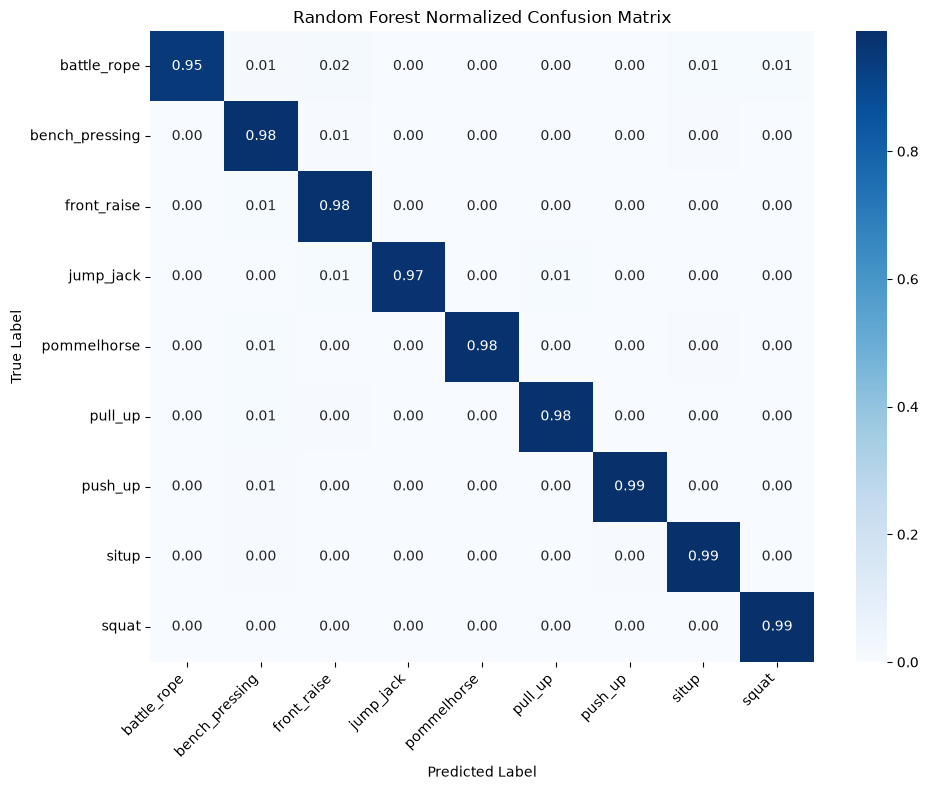

In [90]:
# Normalized Random Forest Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm_normalized = confusion_matrix(
    y_test,
    y_pred_rf,
    normalize="true"
)


plt.figure(figsize=(10,8))


sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)


plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "Random Forest Normalized Confusion Matrix"
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()


### Observation

- The normalized confusion matrix shows that most predictions are concentrated along the diagonal, indicating accurate classification across all exercise classes.
- Random Forest achieved high class-wise recognition performance, with most exercise categories achieving approximately 97–99% prediction accuracy.
- Classes such as push_up, situp, and squat achieved around 99% correct classification, showing excellent model capability.
- Minor misclassification is observed between visually similar exercise movements such as battle_rope and front_raise due to similar pose patterns.
- The low off-diagonal values indicate that the model has learned distinct pose feature patterns for different exercise categories.
- Overall, the confusion matrix confirms that Random Forest is a reliable classical ML model for exercise classification using extracted pose features.

# Artificial Neural Network (ANN) Model Building

An Artificial Neural Network is developed to learn complex relationships between extracted pose features and exercise classes. The performance will be compared with the best classical machine learning model.

In [101]:
# Import TensorFlow and Keras libraries

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.16.1


In [99]:
# Convert target labels into one-hot encoded format for ANN

y_train_ann = to_categorical(
    y_train
)

y_test_ann = to_categorical(
    y_test
)


print("ANN Training Target Shape:", y_train_ann.shape)

print("ANN Testing Target Shape:", y_test_ann.shape)

ANN Training Target Shape: (91632, 9)
ANN Testing Target Shape: (22908, 9)


# ANN Architecture Design

The ANN architecture is designed to learn non-linear relationships between extracted pose features and exercise classes. Dense layers are used for feature learning, dropout layers help prevent overfitting, and softmax activation is used for multi-class classification.

In [100]:
# Build Artificial Neural Network Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


ann_model = Sequential()


# Input Layer + First Hidden Layer

ann_model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    )
)


# Dropout for regularization

ann_model.add(
    Dropout(0.3)
)


# Second Hidden Layer

ann_model.add(
    Dense(
        64,
        activation="relu"
    )
)


# Dropout layer

ann_model.add(
    Dropout(0.2)
)


# Output Layer

ann_model.add(
    Dense(
        9,
        activation="softmax"
    )
)


# Display model architecture

ann_model.summary()

c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,865 (101.04 KB)

 Trainable params: 25,865 (101.04 KB)

 Non-trainable params: 0 (0.00 B)

### Observation

- The ANN model was successfully created with an input layer accepting 132 pose-based features and an output layer containing 9 exercise classes.
- Two dense layers with ReLU activation were used to learn non-linear relationships between extracted pose features and exercise categories.
- Dropout layers were added to reduce overfitting and improve model generalization.
- The final softmax output layer produces probability distribution across all exercise classes.
- The model contains 25,865 trainable parameters, making it lightweight and suitable for efficient training and deployment.

# ANN Model Compilation

The ANN model is compiled using Adam optimizer, categorical crossentropy loss function, and accuracy as the evaluation metric. Adam provides adaptive learning rate optimization, while categorical crossentropy is suitable for multi-class classification problems.

In [102]:
# Compile ANN Model

ann_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


print("ANN Model Compiled Successfully")

ANN Model Compiled Successfully


# ANN Model Training

The ANN model is trained using scaled pose features. Validation data is used to monitor model performance and detect overfitting during training.

In [103]:
# Train ANN Model

history = ann_model.fit(
    X_train_scaled,
    y_train_ann,
    validation_data=(
        X_test_scaled,
        y_test_ann
    ),
    epochs=50,
    batch_size=64,
    verbose=1
)


print("ANN Training Completed Successfully")

Epoch 1/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6990 - loss: 0.9154 - val_accuracy: 0.8081 - val_loss: 0.5860
Epoch 2/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7832 - loss: 0.6641 - val_accuracy: 0.8466 - val_loss: 0.4713
Epoch 3/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8096 - loss: 0.5830 - val_accuracy: 0.8626 - val_loss: 0.4245
Epoch 4/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8244 - loss: 0.5324 - val_accuracy: 0.8738 - val_loss: 0.3813
Epoch 5/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.8353 - loss: 0.4985 - val_accuracy: 0.8855 - val_loss: 0.3538
Epoch 6/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.8428 - loss: 0.4752 - val_accuracy: 0.8930 - val_loss: 0.3365
Epoch 7/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8469 - loss: 0.4586 - val_accuracy: 0.8999 - val_loss: 0.3136
Epoch 8/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8552 - loss:

### Observation

- The Artificial Neural Network (ANN) model was successfully trained for 50 epochs using scaled pose features.
- The training accuracy improved from approximately 70% in the initial epoch to around 90% at the end of training, showing effective learning of pose feature patterns.
- The validation accuracy increased consistently and reached approximately 94%, indicating good generalization on unseen data.
- The continuous decrease in training and validation loss shows that the model successfully optimized its parameters during training.
- No significant overfitting was observed, as validation performance remained stable throughout the training process.
- The ANN successfully learned complex non-linear relationships between extracted pose features and exercise categories.
- The trained ANN model will be further evaluated and compared with the best classical machine learning model (Random Forest) to determine the final model selection.

# ANN Training History Visualization

Training history is analyzed using accuracy and loss curves to understand model learning behavior and identify possible overfitting or underfitting.

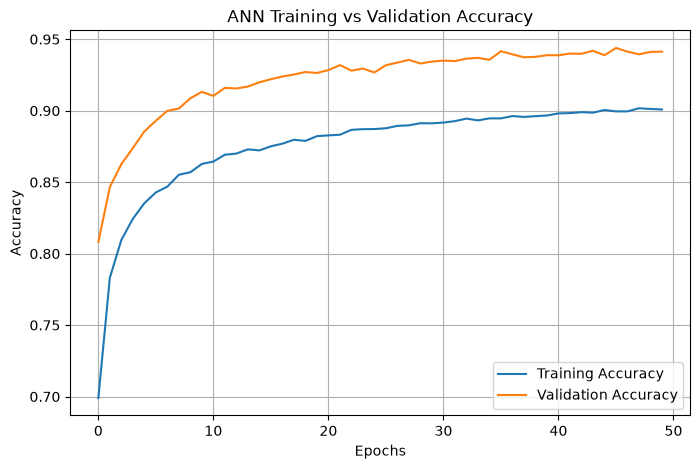

In [104]:
# Plot ANN Training and Validation Accuracy

import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title(
    "ANN Training vs Validation Accuracy"
)


plt.legend()

plt.grid(True)

plt.show()

### Observation

- The ANN accuracy curve shows continuous improvement in both training and validation performance over 50 epochs.
- Training accuracy increased from approximately 70% to 90%, indicating that the model successfully learned patterns from pose-based features.
- Validation accuracy reached approximately 94%, demonstrating good generalization on unseen data.
- The validation accuracy remained consistently higher than training accuracy due to the use of dropout regularization during training.
- No significant overfitting is observed as both curves follow a similar increasing trend and remain stable.
- The ANN model effectively learns non-linear relationships between extracted pose features and exercise categories.

## ANN Loss Curve Visualization

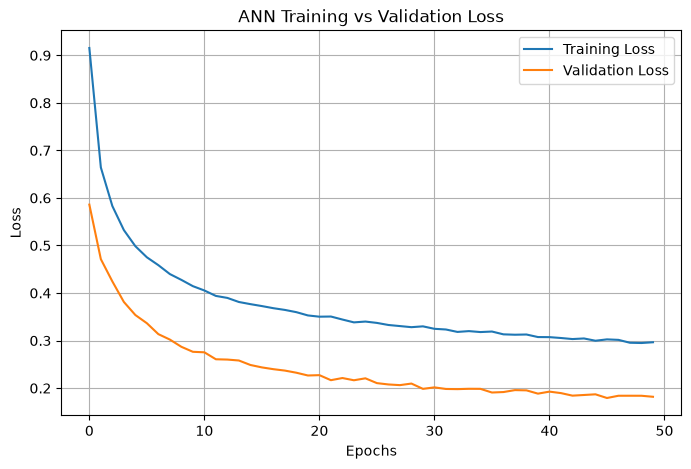

In [105]:
# Plot ANN Training and Validation Loss

plt.figure(figsize=(8,5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title(
    "ANN Training vs Validation Loss"
)


plt.legend()

plt.grid(True)

plt.show()

### Observation

- The ANN loss curve shows a continuous decrease in both training and validation loss throughout the 50 epochs.
- Training loss reduced from approximately 0.91 to 0.29, indicating effective optimization of model parameters.
- Validation loss decreased from approximately 0.58 to 0.18, showing improved performance on unseen data.
- The smooth reduction in loss confirms stable learning without major fluctuations.
- No overfitting is observed because validation loss continues to decrease along with training loss.
- The ANN model successfully converged and learned meaningful patterns from the extracted pose features.

# ANN Model Evaluation

The trained ANN model is evaluated on the unseen test dataset to measure its classification performance. Test accuracy and loss are calculated to understand how well the model generalizes to new data.

In [106]:
# Evaluate ANN Model on Test Dataset

test_loss, test_accuracy = ann_model.evaluate(
    X_test_scaled,
    y_test_ann,
    verbose=0
)


print("ANN Test Loss:", test_loss)

print("ANN Test Accuracy:", test_accuracy)

ANN Test Loss: 0.18178968131542206
ANN Test Accuracy: 0.9413305521011353


### Observation

- The ANN model achieved approximately 94.13% accuracy on the unseen test dataset.
- The test loss value of 0.1818 indicates that the model successfully minimized classification error during evaluation.
- The test performance confirms that the ANN model can effectively classify exercise categories using extracted pose features.
- The ANN achieved good generalization performance, showing that the learned patterns are applicable to unseen samples.
- Although ANN provides strong classification capability, its performance will be compared with the best classical machine learning model (Random Forest) for final model selection.

# ANN Classification Report

The classification report provides class-wise performance evaluation of the ANN model using precision, recall, and F1-score metrics for each exercise category.

In [107]:
# Generate ANN Predictions

import numpy as np


y_pred_ann_prob = ann_model.predict(
    X_test_scaled
)


# Convert probability output to class labels

y_pred_ann = np.argmax(
    y_pred_ann_prob,
    axis=1
)


print("ANN Predictions Generated Successfully")

716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
ANN Predictions Generated Successfully


In [108]:
from sklearn.metrics import classification_report


print("ANN Classification Report\n")


print(
    classification_report(
        y_test,
        y_pred_ann,
        target_names=label_encoder.classes_
    )
)

ANN Classification Report

                precision    recall  f1-score   support

   battle_rope       0.86      0.90      0.88       227
bench_pressing       0.91      0.91      0.91      3145
   front_raise       0.88      0.92      0.90      2146
     jump_jack       0.95      0.94      0.95      2215
   pommelhorse       0.96      0.97      0.96      1521
       pull_up       0.95      0.94      0.95      3309
       push_up       0.95      0.96      0.96      3621
         situp       0.96      0.94      0.95      3232
         squat       0.97      0.95      0.96      3492

      accuracy                           0.94     22908
     macro avg       0.93      0.94      0.93     22908
  weighted avg       0.94      0.94      0.94     22908



### Observation

- The ANN model achieved approximately 94% overall accuracy on the test dataset.
- Most exercise categories achieved high F1-scores between 0.90 and 0.96, showing effective classification performance.
- Exercises such as push_up, squat, pommelhorse, and pull_up achieved strong recognition performance with F1-scores around 0.95 or above.
- The battle_rope class achieved comparatively lower performance (F1-score: 0.88), indicating some confusion with visually similar body movement patterns.
- The macro and weighted average scores are around 0.93 and 0.94 respectively, confirming balanced model performance across different classes.
- The ANN model successfully learned non-linear relationships from extracted pose features and provides a strong deep learning baseline for comparison with Random Forest.

# ANN Confusion Matrix Analysis

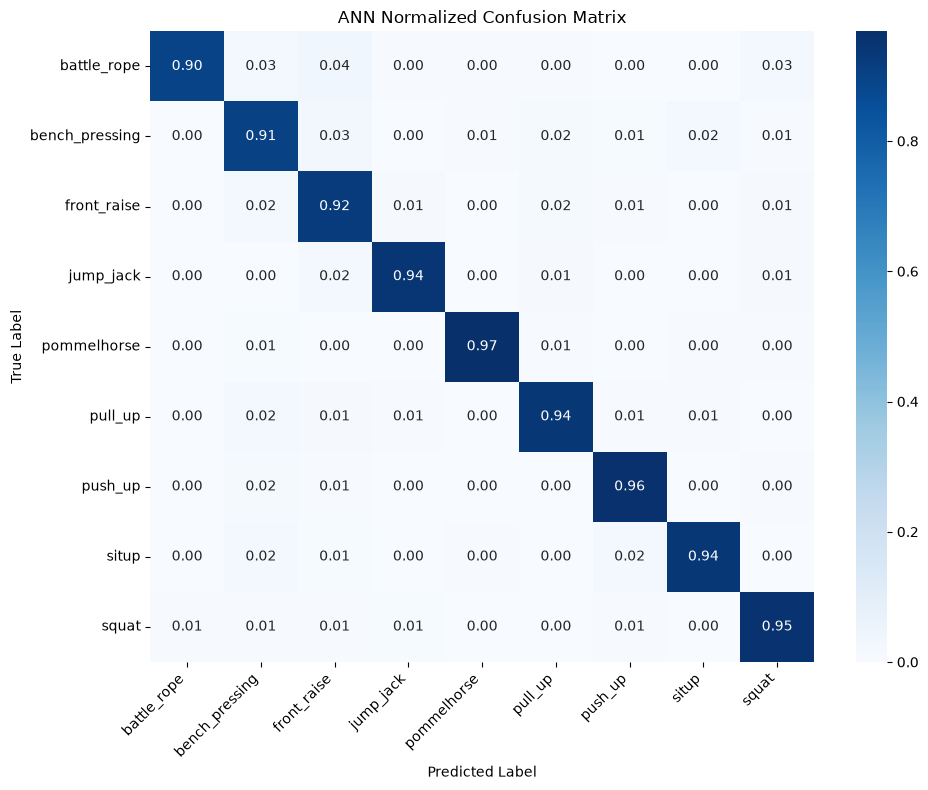

In [109]:
# Generate ANN Normalized Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm_ann = confusion_matrix(
    y_test,
    y_pred_ann,
    normalize="true"
)


plt.figure(figsize=(10,8))


sns.heatmap(
    cm_ann,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)


plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "ANN Normalized Confusion Matrix"
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()

### Observation

- The normalized confusion matrix shows that most predictions are concentrated along the diagonal, indicating strong classification performance by the ANN model.
- The ANN model achieved high class-wise recognition accuracy, with most exercise categories showing 90% or above correct classification.
- Classes such as pommelhorse, push_up, and squat achieved the highest recognition performance with approximately 95–97% accuracy.
- The battle_rope class achieved comparatively lower accuracy (~90%) due to similarity in movement patterns with other exercises.
- Minor confusion is observed between visually similar exercises such as battle_rope, front_raise, and bench_pressing.
- The low off-diagonal values indicate that the ANN model successfully learned meaningful patterns from pose-based features.
- Overall, the confusion matrix confirms that ANN provides reliable exercise classification performance.

# Random Forest vs ANN Model Comparison

The performance of the best classical machine learning model (Random Forest) is compared with the Artificial Neural Network (ANN) model using evaluation metrics such as accuracy, precision, recall, and F1-score.

In [110]:
# Create Final Model Comparison Table

model_comparison_final = pd.DataFrame({

    "Model": [
        "Random Forest",
        "ANN"
    ],

    "Accuracy": [
        0.9811,
        test_accuracy
    ]

})


model_comparison_final

,Model,Accuracy
0,Random Forest,0.981100
1,ANN,0.941331


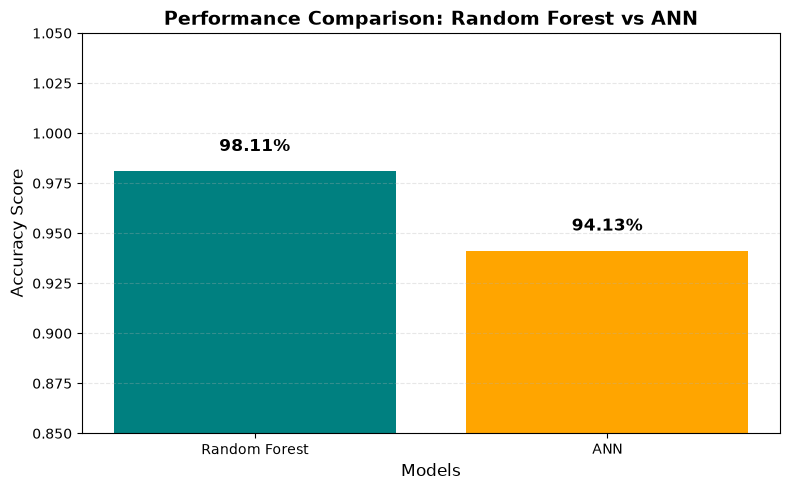

In [117]:

comparison_sorted = model_comparison_final.sort_values(
    by="Accuracy",
    ascending=False
)


plt.figure(figsize=(8,5))


colors = [
    "teal",
    "orange"
]


bars = plt.bar(
    comparison_sorted["Model"],
    comparison_sorted["Accuracy"],
    color=colors
)


# Add percentage labels

for bar, value in zip(
    bars,
    comparison_sorted["Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.2%}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )


plt.xlabel(
    "Models",
    fontsize=12
)

plt.ylabel(
    "Accuracy Score",
    fontsize=12
)


plt.title(
    "Performance Comparison: Random Forest vs ANN",
    fontsize=14,
    fontweight="bold"
)


plt.ylim(
    0.85,
    1.05
)


plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()

plt.show()

### Observation

- The baseline performance comparison shows that Random Forest achieved higher accuracy (98.11%) compared to the ANN model (94.13%).
- Random Forest demonstrated superior performance on the extracted pose features, indicating that tree-based models are highly effective for this classification task.
- ANN also achieved good classification performance by learning complex non-linear patterns from the pose features.
- However, the baseline ANN model could not outperform Random Forest in terms of test accuracy.
- Since Random Forest provided better baseline performance, hyperparameter tuning will be performed to further optimize both Random Forest and ANN models.
- The tuned models will be evaluated again and compared based on accuracy, classification metrics, and real-time prediction performance to select the final model.

# Random Forest Hyperparameter Tuning

Hyperparameter tuning is performed to optimize the Random Forest model by searching for the best combination of parameters that improves classification performance and generalization.

In [118]:
# Import libraries for Random Forest tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [119]:
# Define Random Forest Hyperparameter Grid

rf_param_grid = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        20,
        30
    ],

    "min_samples_split": [
        2,
        5
    ],

    "min_samples_leaf": [
        1,
        2
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]

}


print("Parameter Grid Created Successfully")

Parameter Grid Created Successfully


In [120]:
# Initialize Random Forest Model

rf_tuning_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


print("Random Forest Model Initialized")

Random Forest Model Initialized


In [121]:
# Initialize GridSearchCV for Random Forest Tuning

rf_grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=rf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)


print("Grid Search Setup Completed")

Grid Search Setup Completed


In [122]:
# Start Random Forest Hyperparameter Tuning

rf_grid_search.fit(
    X_train_scaled,
    y_train
)


print("Random Forest Hyperparameter Tuning Completed")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Random Forest Hyperparameter Tuning Completed


## Best Hyperparameters

The optimal hyperparameter combination obtained from GridSearchCV is selected based on the highest cross-validation accuracy.

In [123]:
# Display Best Hyperparameters

print("Best Hyperparameters:")
print(rf_grid_search.best_params_)


print("\nBest Cross Validation Accuracy:")
print(rf_grid_search.best_score_)

Best Hyperparameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross Validation Accuracy:
0.9736118386589837


In [124]:
# Extract Best Tuned Random Forest Model

tuned_rf_model = rf_grid_search.best_estimator_


print("Tuned Random Forest Model Created Successfully")

Tuned Random Forest Model Created Successfully


## Tuned Random Forest Prediction

The optimized Random Forest model is evaluated on the unseen test dataset to measure its generalization performance.

In [125]:
# Generate Predictions using Tuned RF

y_pred_rf_tuned = tuned_rf_model.predict(
    X_test_scaled
)


print("Tuned Random Forest Predictions Generated Successfully")

Tuned Random Forest Predictions Generated Successfully


In [126]:
from sklearn.metrics import accuracy_score


rf_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_rf_tuned
)


print(
    "Tuned Random Forest Accuracy:",
    rf_tuned_accuracy
)

Tuned Random Forest Accuracy: 0.9821023223328095


In [127]:
from sklearn.metrics import classification_report


print("Tuned Random Forest Classification Report\n")


print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=label_encoder.classes_
    )
)

Tuned Random Forest Classification Report

                precision    recall  f1-score   support

   battle_rope       1.00      0.96      0.98       227
bench_pressing       0.97      0.98      0.97      3145
   front_raise       0.97      0.98      0.97      2146
     jump_jack       0.99      0.98      0.98      2215
   pommelhorse       0.98      0.98      0.98      1521
       pull_up       0.98      0.98      0.98      3309
       push_up       0.98      0.99      0.99      3621
         situp       0.99      0.99      0.99      3232
         squat       0.99      0.99      0.99      3492

      accuracy                           0.98     22908
     macro avg       0.98      0.98      0.98     22908
  weighted avg       0.98      0.98      0.98     22908



In [128]:
from sklearn.metrics import classification_report


print("Tuned Random Forest Classification Report\n")


print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=label_encoder.classes_
    )
)

Tuned Random Forest Classification Report

                precision    recall  f1-score   support

   battle_rope       1.00      0.96      0.98       227
bench_pressing       0.97      0.98      0.97      3145
   front_raise       0.97      0.98      0.97      2146
     jump_jack       0.99      0.98      0.98      2215
   pommelhorse       0.98      0.98      0.98      1521
       pull_up       0.98      0.98      0.98      3309
       push_up       0.98      0.99      0.99      3621
         situp       0.99      0.99      0.99      3232
         squat       0.99      0.99      0.99      3492

      accuracy                           0.98     22908
     macro avg       0.98      0.98      0.98     22908
  weighted avg       0.98      0.98      0.98     22908



## Baseline vs Tuned Random Forest Comparison

The baseline Random Forest model is compared with the optimized model to analyze the impact of hyperparameter tuning.

In [129]:
# Create RF Comparison Table

rf_comparison = pd.DataFrame({

    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        0.9811,
        rf_tuned_accuracy
    ]

})


rf_comparison

,Model,Accuracy
0,Baseline Random Forest,0.981100
1,Tuned Random Forest,0.982102


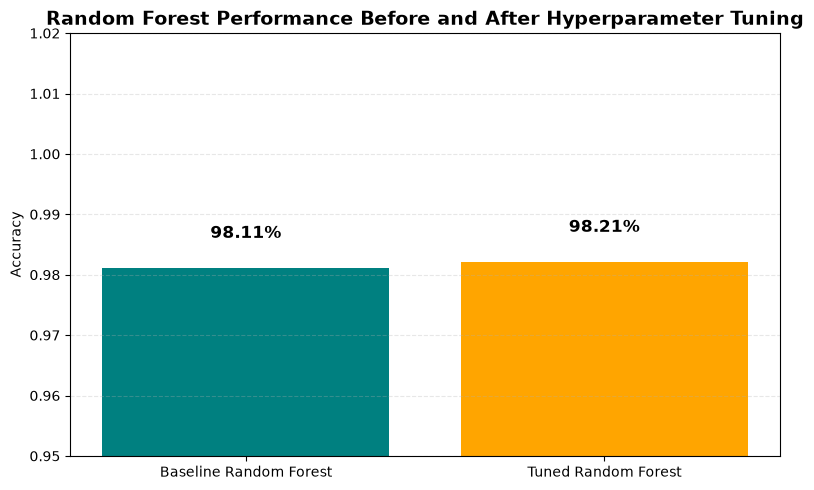

In [130]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


bars = plt.bar(
    rf_comparison["Model"],
    rf_comparison["Accuracy"],
    color=[
        "teal",
        "orange"
    ]
)


for bar, value in zip(
    bars,
    rf_comparison["Accuracy"]
):
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.005,
        f"{value:.2%}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )


plt.title(
    "Random Forest Performance Before and After Hyperparameter Tuning",
    fontsize=14,
    fontweight="bold"
)


plt.ylabel(
    "Accuracy"
)


plt.ylim(
    0.95,
    1.02
)


plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()

plt.show()

In [131]:
import joblib


joblib.dump(
    tuned_rf_model,
    "models/random_forest_tuned.pkl"
)


print("Tuned Random Forest Saved Successfully")

Tuned Random Forest Saved Successfully


# ANN Hyperparameter Tuning

The ANN architecture is optimized by increasing model capacity, adding batch normalization, and applying regularization techniques to improve generalization performance.

In [132]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("ANN Tuning Libraries Imported Successfully")

ANN Tuning Libraries Imported Successfully


In [133]:
# Create Tuned ANN Model

tuned_ann_model = Sequential()


# First Hidden Layer

tuned_ann_model.add(
    Dense(
        256,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    )
)

tuned_ann_model.add(
    BatchNormalization()
)

tuned_ann_model.add(
    Dropout(0.3)
)


# Second Hidden Layer

tuned_ann_model.add(
    Dense(
        128,
        activation="relu"
    )
)

tuned_ann_model.add(
    BatchNormalization()
)

tuned_ann_model.add(
    Dropout(0.3)
)


# Third Hidden Layer

tuned_ann_model.add(
    Dense(
        64,
        activation="relu"
    )
)

tuned_ann_model.add(
    Dropout(0.2)
)


# Output Layer

tuned_ann_model.add(
    Dense(
        y_train_ann.shape[1],
        activation="softmax"
    )
)


tuned_ann_model.summary()

c:\Users\panig\OneDrive\Pictures\Desktop\AI-Based Exercise & Yoga Pose Detection System\project_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,321 (302.04 KB)

 Trainable params: 76,553 (299.04 KB)

 Non-trainable params: 768 (3.00 KB)

In [134]:
# Compile Tuned ANN Model

tuned_ann_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)


print("Tuned ANN Compiled Successfully")

Tuned ANN Compiled Successfully


In [135]:
# Early Stopping Callback

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)


print("Early Stopping Configured")

Early Stopping Configured


## Tuned ANN Model Training

The optimized ANN model is trained using the extracted pose features. Early stopping is applied to prevent overfitting and restore the best performing model weights.

In [136]:
# Train Tuned ANN Model

tuned_ann_history = tuned_ann_model.fit(
    X_train_scaled,
    y_train_ann,
    validation_data=(
        X_test_scaled,
        y_test_ann
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stop
    ],
    verbose=1
)


print("Tuned ANN Training Completed Successfully")

Epoch 1/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7146 - loss: 0.8695 - val_accuracy: 0.8327 - val_loss: 0.4999
Epoch 2/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7976 - loss: 0.6124 - val_accuracy: 0.8624 - val_loss: 0.4117
Epoch 3/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8253 - loss: 0.5306 - val_accuracy: 0.8920 - val_loss: 0.3374
Epoch 4/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8413 - loss: 0.4824 - val_accuracy: 0.8977 - val_loss: 0.3058
Epoch 5/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8512 - loss: 0.4490 - val_accuracy: 0.9075 - val_loss: 0.2875
Epoch 6/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8608 - loss: 0.4230 - val_accuracy: 0.9140 - val_loss: 0.2634
Epoch 7/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8675 - loss: 0.4014 - val_accuracy: 0.9189 - val_loss: 0.2458
Epoch 8/50
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8714 - loss: 0.3871 - 

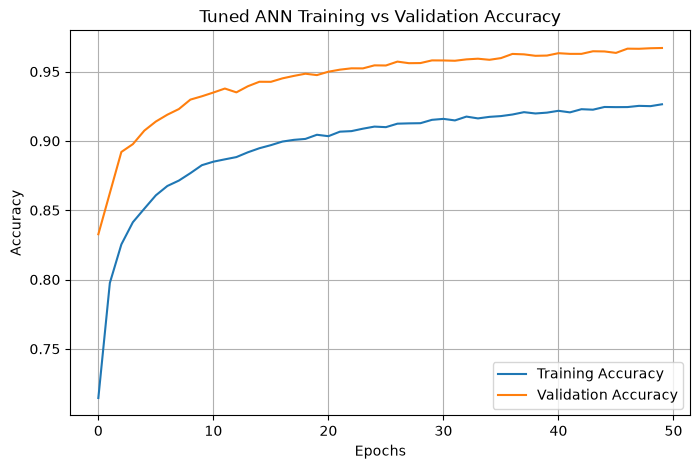

In [138]:
# Tuned ANN Accuracy Curve

plt.figure(figsize=(8,5))


plt.plot(
    tuned_ann_history.history["accuracy"],
    label="Training Accuracy"
)


plt.plot(
    tuned_ann_history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title(
    "Tuned ANN Training vs Validation Accuracy"
)


plt.legend()

plt.grid(True)

plt.show()

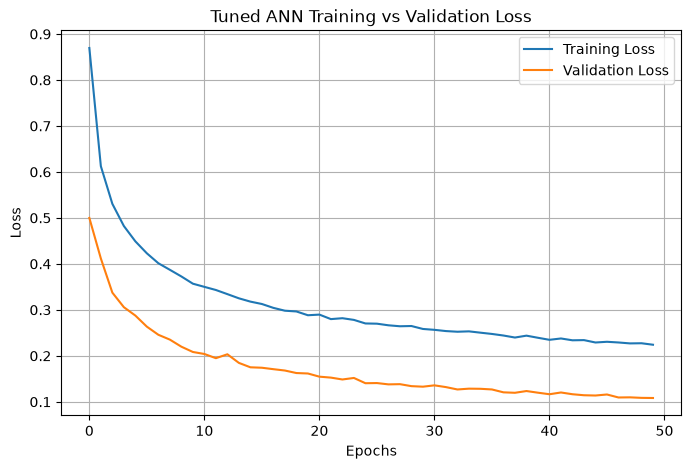

In [139]:
# Tuned ANN Loss Curve

plt.figure(figsize=(8,5))


plt.plot(
    tuned_ann_history.history["loss"],
    label="Training Loss"
)


plt.plot(
    tuned_ann_history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title(
    "Tuned ANN Training vs Validation Loss"
)


plt.legend()

plt.grid(True)

plt.show()

In [140]:
# Evaluate Tuned ANN on Test Data

tuned_test_loss, tuned_test_accuracy = tuned_ann_model.evaluate(
    X_test_scaled,
    y_test_ann,
    verbose=0
)


print("Tuned ANN Test Loss:", tuned_test_loss)

print("Tuned ANN Test Accuracy:", tuned_test_accuracy)

Tuned ANN Test Loss: 0.10824482142925262
Tuned ANN Test Accuracy: 0.967042088508606


In [142]:
# Generate Predictions using Tuned ANN

tuned_y_pred_prob = tuned_ann_model.predict(
    X_test_scaled,
    verbose=0
)

# Convert probabilities to class labels

tuned_y_pred_ann = np.argmax(
    tuned_y_pred_prob,
    axis=1
)

print("Tuned ANN Predictions Generated Successfully")

Tuned ANN Predictions Generated Successfully


In [143]:
from sklearn.metrics import classification_report


print(
    classification_report(
        y_test,
        tuned_y_pred_ann,
        target_names=label_encoder.classes_
    )
)

                precision    recall  f1-score   support

   battle_rope       0.96      0.93      0.94       227
bench_pressing       0.95      0.95      0.95      3145
   front_raise       0.95      0.95      0.95      2146
     jump_jack       0.96      0.97      0.96      2215
   pommelhorse       0.97      0.98      0.97      1521
       pull_up       0.97      0.97      0.97      3309
       push_up       0.97      0.97      0.97      3621
         situp       0.97      0.97      0.97      3232
         squat       0.98      0.97      0.98      3492

      accuracy                           0.97     22908
     macro avg       0.97      0.96      0.96     22908
  weighted avg       0.97      0.97      0.97     22908



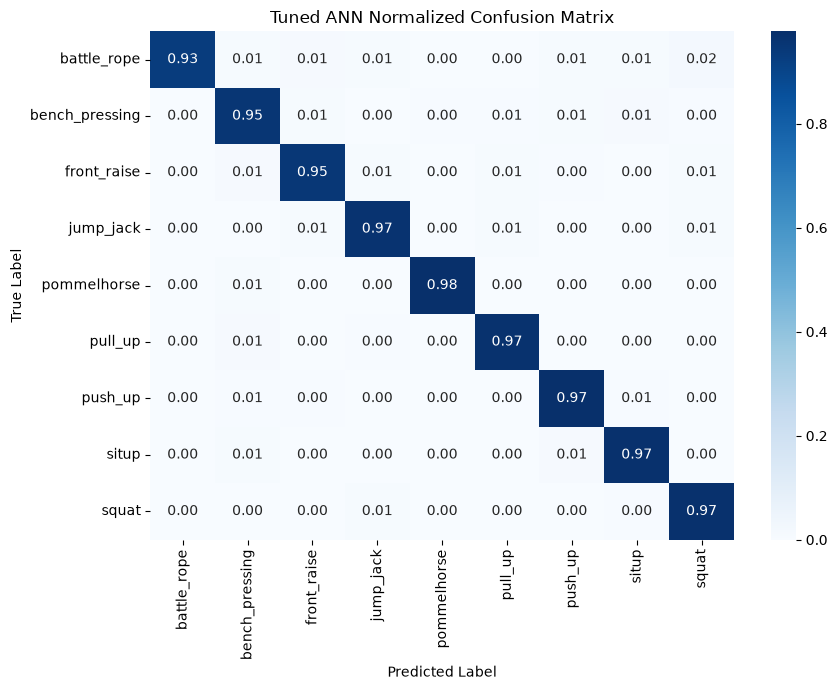

In [144]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    tuned_y_pred_ann,
    normalize="true"
)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Tuned ANN Normalized Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

In [145]:
# Save Tuned ANN Model

tuned_ann_model.save(
    "models/tuned_ann_model.keras"
)


print("Tuned ANN Model Saved Successfully")

Tuned ANN Model Saved Successfully


### Observation

- Hyperparameter tuning improved the ANN model accuracy from **94.13%** to **96.70%**.
- Most exercise classes achieved between **95% and 98%** classification accuracy.
- The confusion matrix shows strong diagonal values with very few misclassifications.
- Exercise categories such as **jump_jack, pommelhorse, pull_up, push_up, situp, and squat** achieved approximately **97–98%** recognition accuracy.
- The **battle_rope** class remains comparatively more challenging with around **93%** accuracy due to similarity in body movement patterns.
- Overall, the tuned ANN demonstrates significantly improved generalization and provides a much stronger deep learning baseline than the initial ANN model.

# Final Model Comparison

This section compares the performance of all developed machine learning and deep learning models. The comparison includes baseline models as well as their optimized versions after hyperparameter tuning.

In [146]:
# Final Model Comparison

final_model_comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "XGBoost",
        "Random Forest",
        "Tuned Random Forest",
        "Baseline ANN",
        "Tuned ANN"
    ],

    "Accuracy":[
        0.7576,
        0.9121,
        0.9744,
        0.9591,
        0.9811,
        0.9821,
        0.9413,
        tuned_test_accuracy
    ]

})

final_model_comparison

,Model,Accuracy
0,Logistic Regression,0.757600
1,Decision Tree,0.912100
2,KNN,0.974400
3,XGBoost,0.959100
4,Random Forest,0.981100
5,Tuned Random Forest,0.982100
6,Baseline ANN,0.941300
7,Tuned ANN,0.967042


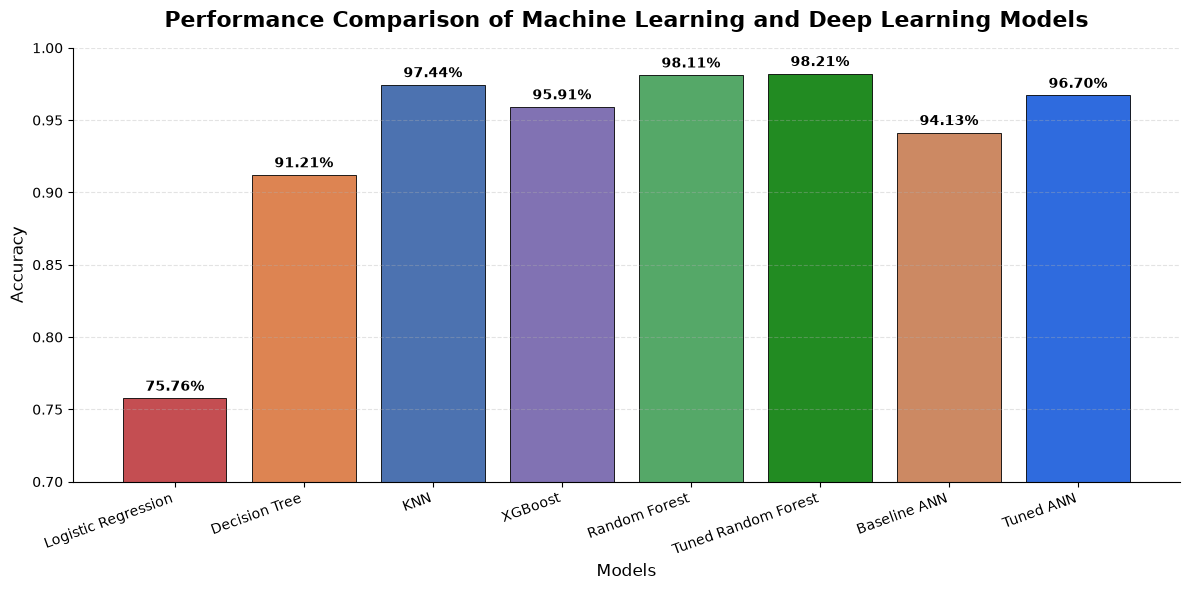

In [148]:
import matplotlib.pyplot as plt

plt.style.use("default")

fig, ax = plt.subplots(figsize=(12,6))

# Professional Colors
colors = [
    "#C44E52",   # Logistic Regression
    "#DD8452",   # Decision Tree
    "#4C72B0",   # KNN
    "#8172B3",   # XGBoost
    "#55A868",   # Random Forest
    "#228B22",   # Tuned Random Forest (Highlighted)
    "#CC8963",   # Baseline ANN
    "#2F6BDE"    # Tuned ANN
]

bars = ax.bar(
    final_model_comparison["Model"],
    final_model_comparison["Accuracy"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

# Labels
for bar, value in zip(bars, final_model_comparison["Accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.003,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Formatting
ax.set_title(
    "Performance Comparison of Machine Learning and Deep Learning Models",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("Models", fontsize=12)

ax.set_ylim(0.70, 1.00)

plt.xticks(rotation=20, ha="right")

# Light Grid
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Observation

- Logistic Regression achieved the lowest classification accuracy (**75.76%**), indicating that the extracted pose features are not linearly separable.
- Decision Tree improved performance to **91.21%**, while K-Nearest Neighbors achieved **97.44%**, demonstrating strong capability in distinguishing exercise pose patterns.
- XGBoost achieved **95.91%** accuracy, providing robust gradient boosting performance on the extracted pose features.
- Random Forest achieved the highest performance among the baseline machine learning models with **98.11%** accuracy.
- Hyperparameter tuning further improved Random Forest performance to **98.21%**, making it the overall best-performing model.
- The baseline Artificial Neural Network achieved **94.13%** accuracy, while hyperparameter tuning increased its performance to **96.70%**, reducing the gap with Random Forest.
- Overall, classical machine learning models slightly outperformed deep learning models because the system uses handcrafted MediaPipe pose features instead of raw images. The tuned Random Forest was selected as the final deployment model due to its superior accuracy and computational efficiency.

# Model Export and Deployment Artifacts

This section saves the final trained models and preprocessing objects required for deployment. These artifacts will be used by the real-time exercise recognition application without retraining the models.

In [149]:
# Save Final Exercise Random Forest Model

import joblib

joblib.dump(
    tuned_rf_model,
    "models/exercise_random_forest.pkl"
)

print("Exercise Random Forest Model Saved Successfully")

Exercise Random Forest Model Saved Successfully


In [150]:
# Save Final Exercise ANN Model

tuned_ann_model.save(
    "models/exercise_ann.keras"
)

print("Exercise ANN Model Saved Successfully")

Exercise ANN Model Saved Successfully


In [151]:
# Save Preprocessing Objects

joblib.dump(
    scaler,
    "models/scaler_exercise.pkl"
)

joblib.dump(
    label_encoder,
    "models/label_encoder_exercise.pkl"
)

print("Exercise Scaler Saved Successfully")
print("Exercise Label Encoder Saved Successfully")

Exercise Scaler Saved Successfully
Exercise Label Encoder Saved Successfully


In [152]:
# Verify Deployment Artifacts

import os

print("=" * 55)
print(" Exercise Model Deployment Artifacts")
print("=" * 55)

for file in sorted(os.listdir("models")):
    print(file)

 Exercise Model Deployment Artifacts
exercise_ann.keras
exercise_random_forest.pkl
label_encoder.pkl
label_encoder_exercise.pkl
random_forest_model.pkl
random_forest_tuned.pkl
scaler.pkl
scaler_exercise.pkl
tuned_ann_model.keras
